## **Authors**

*The work can be done in groups of up to 3 students. Please complete the following fields with your group number and list your names along with ISU ID numbers.*

> **Technical Vision**
>
> 1. Кормушкина Ксения, 466278
> 2. Носуленко Егор, 466921

*The task and guidelines were prepared by Andrei Zhdanov and Sergei Shavetov, ITMO University, 2025.*

# **Practical Assignment No 3. Filtering and Edges Detection**

*Studying of the filtering images basic methods and edges detection.*

*Изучение основных методов фильтрации изображений и обнаружения границ.*

## **Task 1. Noises types**

*Select an arbitrary image. Get images distorted by various noises with parameters other than the default values.*

*Выберите произвольное изображение. Получите изображения, искаженные различными шумами с параметрами, отличными от значений по умолчанию.*

### **1.1 Preparation**

First, we need to add some imports for OpenCV to work. Python implementation of OpenCV is in `cv2` library, but for convenience it will be imported as `cv`.

Сначала нам нужно добавить несколько импортов для работы OpenCV. Python-реализация OpenCV находится в библиотеке `cv2`, но для удобства она будет импортирована как `cv`.

In [11]:
# Import OpenCV library both as cv and cv2
import cv2 as cv
# Import NumPy library both as np and numpy
import numpy as np
# Import skimage for noise generation functions
import skimage
# Import sys for general constants
import sys

Also we will import `ShowImages()` function from the first practical assignment to use it here. It is placed in `pa_utils`.

Также мы импортируем функцию `ShowImages()` из первого практического задания для использования здесь. Она находится в `pa_utils`.

In [12]:
from pa_utils import ShowImages

### **1.2 Read and display an image**

Now let's open our image which we will use during the current task. We will open it in BGR and convert to grayscale. We will use previously introduced functions for image display.

Теперь давайте откроем наше изображение, которое мы будем использовать в ходе текущего задания. Мы откроем его в формате BGR и преобразуем в оттенки серого. Мы будем использовать ранее представленные функции для отображения изображений.

In [ ]:
# Read an image from file in BGR
fn = "images/lena_color.png"
I = cv.imread(fn, cv.IMREAD_COLOR)
if not isinstance(I, np.ndarray) or I.data == None:
  print("Error reading file \"{}\"".format(fn))
else:
  # Convert BGR to grayscale
  I = cv.cvtColor(I, cv.COLOR_BGR2GRAY)
  # Display it
  ShowImages([("Source image", I)])

### **1.3 Noises**

Digital images obtained by various optoelectronic devices can contain various distortions caused by various kinds of interference, which are commonly called *noise*. The noise in the image makes it difficult to process it automatically. The noises have a different nature, and for its successful suppression it is necessary to determine an adequate mathematical model. Let's consider the most common noise models. When using OpenCV noise have to be added manually, however the `skimage` Python toolbox provides `skimage.util.random_noise()` function which allows adding noise. We will try both ways.

Цифровые изображения, полученные различными оптоэлектронными устройствами, могут содержать различные искажения, вызванные разного рода помехами, которые принято называть *шумом*. Шум на изображении затрудняет его автоматическую обработку. Шумы имеют различную природу, и для его успешного подавления необходимо определить адекватную математическую модель. Рассмотрим наиболее распространенные модели шума. При использовании OpenCV шум необходимо добавлять вручную, однако инструментарий Python `skimage` предоставляет функцию `skimage.util.random_noise()`, которая позволяет добавлять шум. Мы опробуем оба способа.

#### **1.3.1 Impulse noise**

With impulse noise, the signal is distorted by spikes with very large negative or positive values of short duration and can arise, for example, due to decoding errors. This noise results in white "*salt*" or black "*pepper*" dots in the image, which is why it is often called *dot* noise. To describe it, one should take into account the fact that the appearance of a noise spike in each pixel $I(x,y)$ does not depend on the quality of the original image or on the presence of noise at other points and has the probability of $p$, and the value of the pixel intensity $I(x,y)$ will be changed to value $d\in[0,255]$:

При импульсном шуме сигнал искажается выбросами с очень большими отрицательными или положительными значениями малой длительности и может возникать, например, из-за ошибок декодирования. Этот шум проявляется в виде белых "*соль*" или черных "*перец*" точек на изображении, поэтому его часто называют *точечным* шумом. Для его описания следует учитывать тот факт, что появление шумового выброса в каждом пикселе $I(x,y)$ не зависит от качества исходного изображения или от наличия шума в других точках и имеет вероятность $p$, а значение интенсивности пикселя $I(x,y)$ будет изменено на значение $d\in[0,255]$:

$$
	I_{noisy}(x,y) = 
	\begin{cases}
		d      & ~\text{with probability}~p    \\
		I(x,y) & ~\text{with probability}~(1-p)
	\end{cases}
$$

where $I(x,y)$ is the pixel intensity of the original image, $I_{noisy}$ is the noisy image, and $p$ is the nose ratio. If $d=0$ then the noise "*pepper*" type, if $d=255$ then noise is "*salt*".

где $I(x,y)$ — интенсивность пикселя исходного изображения, $I_{noisy}$ — зашумленное изображение, а $p$ — доля шума. Если $d=0$, то шум типа "*перец*", если $d=255$, то шум типа "*соль*".

Let's implement the impulse noise. As for the *salt* type noise we have to add the maximum value, we will consider that only floating point images with $1.0$ maximum value, or `uint8` ones with $255$ maximum value are supported. The noise is controlled by two values: the noise probability (`p`) and salt versus pepper ratio (`s_vs_p`).

Давайте реализуем импульсный шум. Что касается шума типа *соль*, мы должны добавить максимальное значение, поэтому мы будем считать, что поддерживаются только изображения с плавающей точкой с максимальным значением $1.0$, или изображения `uint8` с максимальным значением $255$. Шум управляется двумя значениями: вероятностью шума (`p`) и соотношением соли и перца (`s_vs_p`).

In [13]:
## Add the salt and pepper noise to an image
## @param[in] image An image 
## @param[in] p Probability of noise
## @param[in] s_vs_p Salt vs pepper distribution
## @return An image with noise
def SaltAndPepper(I, p = 0.05, s_vs_p = 0.5):
  # Select the salt value
  if I.dtype == np.uint8:
    salt = 255
  elif I.dtype == np.float32:
    salt = 1.0
  else:
    print("Unsupported image type")
    return None

  # Create an image
  Inoise = np.copy(I)
  # Get random value for each image poxel
  rng = np.random.default_rng()
  vals = rng.random(Inoise.shape)
  # Add salt
  Inoise[vals < p * s_vs_p] = salt
  # Add pepper
  Inoise[np.logical_and(vals >= p * s_vs_p, vals < p)] = 0
  
  return Inoise

Alternatively, the `skimage.util.random_noise(I, 's&p')` function can be used. Its optional `amount` parameter can be used to modify the "*salt*" and "*pepper*" probabilities. The next optional `salt_vs_pepper`  can be used to set the relative probabilities of "*salt*" and "*pepper*" noises. Only "*salt*" noise can be generated by `skimage.util.random_noise(I, 'salt')` function, while only "*pepper*" can be generated by `skimage.util.random_noise(I, 'pepper')` function. It should also be noted that these methods converts an image to a floating point value image, so additional conversion is required.

Альтернативно можно использовать функцию `skimage.util.random_noise(I, 's&p')`. Ее необязательный параметр `amount` можно использовать для изменения вероятностей "*соли*" и "*перца*". Следующий необязательный параметр `salt_vs_pepper` можно использовать для установки относительных вероятностей шумов "*соли*" и "*перца*". Только шум "*соли*" может быть сгенерирован функцией `skimage.util.random_noise(I, 'salt')`, в то время как только шум "*перца*" может быть сгенерирован функцией `skimage.util.random_noise(I, 'pepper')`. Также следует отметить, что эти методы преобразуют изображение в изображение со значениями с плавающей точкой, поэтому требуется дополнительное преобразование.

Let's run both this methods and compare results.

Давайте запустим оба этих метода и сравним результаты.

In [ ]:
# Own implementation
Isnp = SaltAndPepper(I, 0.1, 0.5)
# Skimage
Isnp2 = (skimage.util.random_noise(I, "s&p", amount = 0.1, salt_vs_pepper = 0.5) * 255).astype(np.uint8)
# Show both
ShowImages([("Salt & Pepper", Isnp), 
            ("SKImage Salt & Pepper", Isnp2)])

We may also approximately calculate the resulting *salt* and *pepper* ratios with simple math transformations. Let's do it.

Мы также можем приблизительно рассчитать результирующие доли *соли* и *перца* с помощью простых математических преобразований. Давайте сделаем это.

In [ ]:
diff = I.astype(np.int32) - Isnp
print("Own implementation salt ratio is {:.2f}%, pepper ratio is {:.2f}%".format(
      100 * np.count_nonzero(diff < 0) / I.shape[0] / I.shape[1], 
      100 * np.count_nonzero(diff > 0) / I.shape[0] / I.shape[1]))
diff2 = I.astype(np.int32) - Isnp2
# As skimage work in floating point values with conversion, 
# so we have to take this into an account and add some epsilon value
print("Skimage implementation salt ratio is {:.2f}%, pepper ratio is {:.2f}%".format(
      100 * np.count_nonzero(diff2 < -1) / I.shape[0] / I.shape[1], 
      100 * np.count_nonzero(diff2 > 1) / I.shape[0] / I.shape[1]))

#### **1.3.2 Additive noise**

Additive noise is described by the following expression:

Аддитивный шум описывается следующим выражением:

$$I_{noisy}(x,y) = I(x,y) + \eta(x,y)$$

where $I_{noisy}$ is the noisy image, $I$ is the original image, and $\eta$ is the signal-independent additive noise with Gaussian or any other probability density function.

где $I_{noisy}$ — зашумленное изображение, $I$ — исходное изображение, а $\eta$ — не зависящий от сигнала аддитивный шум с гауссовской или любой другой функцией плотности вероятности.

We will see an example of an additive noise a bit later in a Gaussian noise section.

Мы увидим пример аддитивного шума чуть позже, в разделе о гауссовском шуме.

#### **1.3.3 Multiplicative Noise**

Multiplicative noise is described by the following expression:

Мультипликативный шум описывается следующим выражением:

$$I_{noisy}(x,y) = I(x,y) \cdot \eta(x,y)$$

where $I_{noisy}$ is the noisy image, $I$ is the original image, and $\eta$ is the signal independent multiplicative noise that multiplies the recorded signal. Examples include film grain, ultrasound images, etc. A special case of multiplicative noise is *speckle* noise. This noise appears in images captured by coherent imaging devices such as medical scanners or radars. In such images, one can clearly observe light spots, speckles, which are separated by dark areas of the image.

где $I_{noisy}$ — зашумленное изображение, $I$ — исходное изображение, а $\eta$ — не зависящий от сигнала мультипликативный шум, который умножает записанный сигнал. Примерами являются зернистость пленки, ультразвуковые изображения и т.д. Частным случаем мультипликативного шума является *спекл*-шум. Этот шум появляется на изображениях, полученных когерентными устройствами визуализации, такими как медицинские сканеры или радары. На таких изображениях можно отчетливо наблюдать светлые пятна, спеклы, которые разделены темными областями изображения.

Let's implement the multiplicative noise with normal distribution which is called the *speckle* noise.

Давайте реализуем мультипликативный шум с нормальным распределением, который называется *спекл*-шумом.

In [14]:
## Add the speckle noise to an image
## @param[in] image An image 
## @param[in] var Random number variance
## @return An image with noise
def Speckle(I, var = 0.05):
  if I.dtype != np.uint8 and I.dtype != np.float32:
      print("Unsupported image values type.")
      return None

  # Generate a random number with normal distribution for each image pixel
  rng = np.random.default_rng()
  gauss = rng.normal(0, var ** 0.5, I.shape)

  # Add a multiple of this distribution to our image
  # The image values type should be taken into an account here 
  # as we should work with floating point values
  if I.dtype == np.uint8:
    out = (I.astype(np.float32) * (gauss + 1)).clip(0, 255).astype(np.uint8)
  else:
    out = I * (gauss + 1)

  return out

This noise can also be applied to an image by using `skimage.util.random_noise(I, 'speckle')`. Optional `mean` and `var` parameters defines the mean and variance for the normal distribution used to generate noise.

Этот шум также можно применить к изображению, используя `skimage.util.random_noise(I, 'speckle')`. Необязательные параметры `mean` и `var` определяют среднее значение и дисперсию для нормального распределения, используемого для генерации шума.

Let's run both this methods and compare results.

Давайте запустим оба этих метода и сравним результаты.

In [ ]:
# Own implementation
Isp = Speckle(I, 0.05)
# Skimage
Isp2 = (skimage.util.random_noise(I, "speckle", mean = 0, var = 0.05) * 255).astype(np.uint8)
# Show both
ShowImages([("Speckle", Isp), 
            ("SKImage Speckle", Isp2)])

#### **1.3.4 Gaussian (Normal) Noise**

Gaussian noise in the additive noise on the image that can occur due to a lack of scene illumination, high temperature, etc. The noise model is widely used in low-pass filtering of images. The probability density distribution function $p(z)$ of the random variable $z$ is described by the following expression:

Гауссовский шум — это аддитивный шум на изображении, который может возникать из-за недостаточного освещения сцены, высокой температуры и т.д. Модель шума широко используется при фильтрации изображений нижних частот. Функция плотности распределения вероятности $p(z)$ случайной величины $z$ описывается следующим выражением:

$$p(z) = \dfrac{1}{\sigma \sqrt{2\pi}}e^{\frac{-(z-\mu)^2}{2\sigma^2}}$$

where $z$ is the the intensity of the image (for example, for a grayscale image $z\in[0,255]$), $\mu$ is the mean (mathematical expectation) of a random variable $z$, $\sigma$ is the standard deviation, variance $\sigma^2$ determines the power of the introduced noise. Approximately $67%$ of the random variable $z$ values is concentrated in the range $\left[(\mu-\sigma),(\mu+\sigma)\right]$ and about $96%$ in the range $\left[(\mu-2\sigma),(\mu+2\sigma)\right]$.

где $z$ — интенсивность изображения (например, для полутонового изображения $z\in[0,255]$), $\mu$ — среднее значение (математическое ожидание) случайной величины $z$, $\sigma$ — среднеквадратическое отклонение, дисперсия $\sigma^2$ определяет мощность вносимого шума. Приблизительно $67%$ значений случайной величины $z$ сосредоточено в диапазоне $\left[(\mu-\sigma),(\mu+\sigma)\right]$ и около $96%$ в диапазоне $\left[(\mu-2\sigma),(\mu+2\sigma)\right]$.

As we know that this is an additive noise and it uses the normal distribution, we can easily implement it.

Поскольку мы знаем, что это аддитивный шум и он использует нормальное распределение, мы можем легко его реализовать.

In [15]:
## Add the Gaussian noise to an image
## @param[in] image An image 
## @param[in] mean Mean value
## @param[in] var Variance
## @return An image with noise
def Gaussian(I, mean = 0, var = 0.01):
  if I.dtype != np.uint8 and I.dtype != np.float32:
    print("Unsupported image values type.")
    return None

  rng = np.random.default_rng()
  gauss = rng.normal(mean, var ** 0.5, I.shape)
  
  if I.dtype == np.uint8:
    out = (I.astype(np.float32) + gauss * 255).clip(0, 255).astype(np.uint8)
  else:
    out = (I + gauss).astype(np.float32)
  
  return out

It can also be applied to an image by using `skimage.util.random_noise(I, 'gaussian')` function. Optional `mean` and `var` parameters defines the mean and variance for the normal distribution used to generate noise. The additional `skimage.util.random_noise(I, 'localvar')` function allows to specify the local random variance for each pixel of the image passed by an extra `local_vars` function parameter.

Его также можно применить к изображению, используя функцию `skimage.util.random_noise(I, 'gaussian')`. Необязательные параметры `mean` и `var` определяют среднее значение и дисперсию для нормального распределения, используемого для генерации шума. Дополнительная функция `skimage.util.random_noise(I, 'localvar')` позволяет указать локальную случайную дисперсию для каждого пикселя изображения, передаваемую через дополнительный параметр функции `local_vars`.

Let's run both this methods and compare results.

Давайте запустим оба этих метода и сравним результаты.

In [ ]:
# Own implementation
Igauss = Gaussian(I, 0, 0.05)
# Skimage
Igauss2 = (skimage.util.random_noise(I, "gaussian", mean = 0, var = 0.05) * 255).astype(np.uint8)
# Show both
ShowImages([("Gaussian", Igauss), 
            ("SKImage Gaussian", Igauss2)])

#### **1.3.5 Quantization Noise**

Depends on the selected quantization step and on the signal. Quantization noise can lead, for example, to the appearance of false contours around objects or to remove low-contrast details in the image. Such noise is not eliminated. Quantization noise can be approximately described by the Poisson distribution.

Зависит от выбранного шага квантования и от сигнала. Шум квантования может привести, например, к появлению ложных контуров вокруг объектов или к удалению низкоконтрастных деталей на изображении. Такой шум не устраняется. Шум квантования можно приблизительно описать распределением Пуассона.

Since we know the distribution type, we can implement this noise.

Поскольку мы знаем тип распределения, мы можем реализовать этот шум.

In [16]:
## Add the poison noise to an image
## @param[in] image An image 
## @return An image with noise
def Poisson(I):
  rng = np.random.default_rng()
  # We have to calculate the number of unique values then add
  # the poisson distribution noise basing on this number to
  # simulate the quantization noise
  if I.dtype == np.uint8:
    Ifloat = I.astype(np.float32) / 255
    vals = len(np.unique(Ifloat))
    vals = 2 ** np.ceil(np.log2(vals))
    out = (255 * (rng.poisson(Ifloat * vals) / float(vals)).clip(0, 1)).astype(np.uint8)
  elif I.dtype == np.float32:
    vals = len(np.unique(I))
    vals = 2 ** np.ceil(np.log2(vals))
    out = rng.poisson(I * vals) / float(vals)
  else:
    print("Unsupported image values type.")
    return None
  
  return out

It can also be applied  by using `skimage.util.random_noise(I, 'poisson')` function.

Его также можно применить с помощью функции `skimage.util.random_noise(I, 'poisson')`.

Let's run both this methods and compare results.

Давайте запустим оба этих метода и сравним результаты.

In [ ]:
# Own implementation
Ipoisson = Poisson(I)
# Skimage
Ipoisson2 = (skimage.util.random_noise(I, "poisson") * 255).astype(np.uint8)
# Show both
ShowImages([("Poisson", Ipoisson), 
            ("SKImage Poisson", Ipoisson2)])

#### **1.3.6 Noise summary**

So, we learned how to add different type of noise. Let's write a copy of MATLAB's `imnoise()` function.

Итак, мы научились добавлять различные типы шума. Давайте напишем копию функции `imnoise()` из MATLAB.

In [17]:
## Add noise to an image
## @param[in] image An image 
## @param[in] noise_type Noise type to add
## @param[in] param1 First noise-dependent parameter
## @param[in] param2 Second noise-dependent parameter
## @return An image with noise
## @note For "salt & pepper" type, param1 is the probability, param2 is the salt vs pepper ratio.
## @note For "speckle" type, param1 is variance.
## @note For "gaussian" type, param1 is mean, param2 is variance.
def imnoise(I, noise_type, param1 = None, param2 = None):
  # Salt & pepper (param1 - probability, param2 - salt vs pepper)
  if noise_type == "salt & pepper":
    if param1 != None:
      d = param1
    else:
      d = 0.05
    if param2 != None:
      s_vs_p = param2
    else:
      s_vs_p = 0.5
    
    return SaltAndPepper(I, d, s_vs_p)

  # Multiplicative Noise (param1 - variance)
  if noise_type =="speckle": # Variance of multiplicative noise, specified as a numeric scalar
    if param1 != None:
      var = param1
    else:
      var = 0.05

    return Speckle(I, var)

  # Gaussian Noise (param1 - mean, param2 - variance)
  if noise_type == "gaussian":
    if param1 != None:
      mean = param1
    else:
      mean = 0
    if param2 != None:
      var = param2
    else:
      var = 0.01

    return Gaussian(I, mean, var)

  # Quantization Noise
  if noise_type == "poisson":
    return Poisson(I)

  return None


Also, let's make a more convenient array of images to test different noise filters.

Также давайте создадим более удобный массив изображений для тестирования различных фильтров шумоподавления.

In [ ]:
Itmp = I # cv.resize(I, (256, 256))
Inoise = [("Salt & Pepper", SaltAndPepper(Itmp, 0.1)), 
          ("Speckle", Speckle(Itmp)), 
          ("Gaussian", Gaussian(Itmp)), 
          ("Poisson", Poisson(Itmp))]
ShowImages(Inoise, 0)

##### **1.3.6.1 Self-work**

> ***Self-work***
>
> Take some arbitrary image and apply different noises to it. Use $6\%$ percent probability for the impulse noise with $1:1$ distribution of salt versus pepper ($50\%$ percent). Show the results and store them in an array to test filters.
>
> ***Самостоятельная работа***
>
> Возьмите произвольное изображение и примените к нему различные шумы. Используйте $6\%$ вероятность для импульсного шума с распределением соли и перца $1:1$ ($50\%$). Покажите результаты и сохраните их в массив для тестирования фильтров.


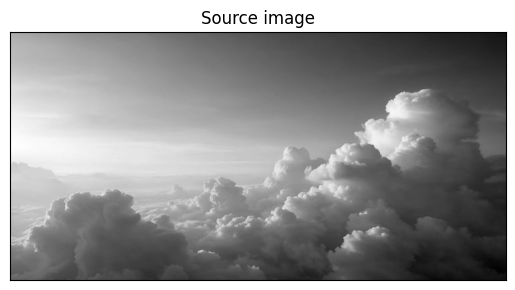

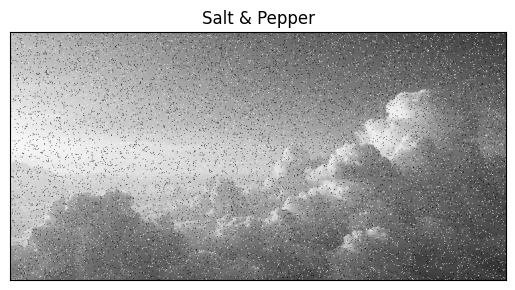

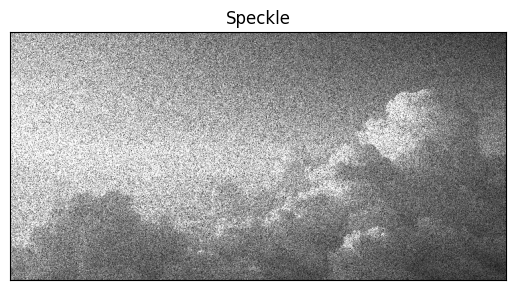

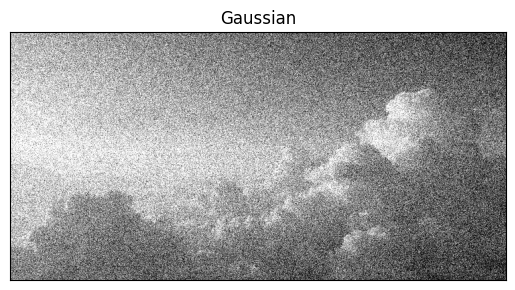

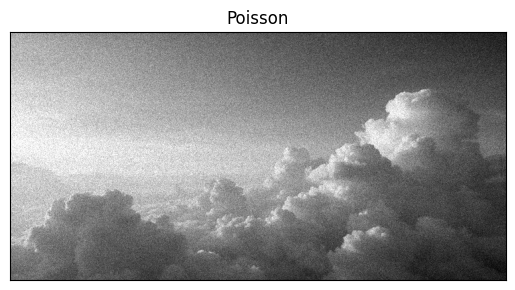

In [18]:
# TODO Place your solution here

# Read an image from file in BGR
fn = "images/our_photo.png"
I = cv.imread(fn, cv.IMREAD_COLOR)
if not isinstance(I, np.ndarray) or I.data == None:
  print("Error reading file \"{}\"".format(fn))
else:
  # Convert BGR to grayscale
  I = cv.cvtColor(I, cv.COLOR_BGR2GRAY)
  # Display it
  ShowImages([("Source image", I)])

p = 0.06
s_vs_p = 0.5

Isnp = SaltAndPepper(I, p, s_vs_p)  # Импульсный шум с значениями, которые нам даны
Isp = Speckle(I, 0.08)  # Спекл-шум, в котором дисперсия = 0.08 (отличается от 0.05 по умолчанию)
Igauss = Gaussian(I, 0, 0.03)   # Гауссов шум, в котором среднее = 0, диспепрсия = 0.03 (отличается от 0.01 по умолчанию)
Ipoisson = Poisson(I)   # Пуассоновский шум

Inoise = [
    ("Salt & Pepper", Isnp),
    ("Speckle", Isp),
    ("Gaussian", Igauss),
    ("Poisson", Ipoisson)
]

ShowImages(Inoise, 0)


## **Task 2. Low-pass filtering**

*Process the distorted images obtained in the previous paragraph with considered low-pass filters and a counterharmonic mean filter with different values of the parameter 𝑄.*

*Обработайте искаженные изображения, полученные в предыдущем пункте, рассмотренными фильтрами нижних частот и контргармоническим средним фильтром с различными значениями параметра Q.*

### **2.1 Sliding window filters**

Let's consider the main methods of image filtering. It the neighboring pixels values in a certain neighborhood are taken into account to calculate th intensity value of the each pixel, then such a transformation is called \text{local}, and the neighborhood is called a *window*. The "window" is called *mask*, *filter*, *filter kernel*, and matrix coefficients are called *coefficients*. The center of the mask is aligned with the analyzed pixel, and the mask coefficients are multiplied by the intensities of the pixels covered by the mask. Typically, the mask has a square shape of $3\times 3$, $5\times 5 $, etc. Filtering an $M\times N$ image $I$ using a mask of $m\times n$ size is described by the formula:

Рассмотрим основные методы фильтрации изображений. Если при вычислении значения интенсивности каждого пикселя учитываются значения соседних пикселей в определенной окрестности, то такое преобразование называется локальным, а окрестность называется окном. "Окно" называется маской, фильтром, ядром фильтра, а коэффициенты матрицы называются коэффициентами. Центр маски совмещается с анализируемым пикселем, а коэффициенты маски умножаются на интенсивности пикселей, покрываемых маской. Обычно маска имеет квадратную форму размером $3\times 3$, $5\times 5 $ и т.д. Фильтрация изображения $I$ размером $M\times N$ с использованием маски размером $m\times n$ описывается формулой:

$$I_{filtered}(x,y) = \sum_s \sum_t w(s,t)I(x+s, y+t)$$

where $s$ and $t$ are the coordinates of the mask elements relative to its center (in the center $s=t=0$). Such transformations are called *linear*. After calculating the new value of the pixel intensity $I_{filtered}(x,y)$ window $w$, n which the filter mask is described, it is shifted and the intensity of the next pixel is calculated. Therefore, such a transformation is called *sliding window filtering*. 

где $s$ и $t$ — координаты элементов маски относительно ее центра (в центре $s=t=0$). Такие преобразования называются линейными. После вычисления нового значения интенсивности пикселя $I_{filtered}(x,y)$ окно $w$, в котором описана маска фильтра, сдвигается, и вычисляется интенсивность следующего пикселя. Поэтому такое преобразование называется фильтрацией со скользящим окном.

When using OpenCV image filtering can be performed by calling the `dst = cv2.filter2D(src, ddest, kernel)` function. Here `src` is an input image matrix, `dst` is an output image matrix, `kernel` is filtering kernel that should be specified manually. Filtering mask can be created manually by creating new numpy matrix, for example:

При использовании OpenCV фильтрацию изображения можно выполнить, вызвав функцию `dst = cv2.filter2D(src, ddepth, kernel)`. Здесь `src` — входная матрица изображения, `dst` — выходная матрица изображения, `kernel` — ядро фильтра, которое должно быть задано вручную. Маску фильтра можно создать вручную, создав новую матрицу numpy, например:

```python
mask = np.float64([[1, 1, 1], [1, 1, 1], [1, 1, 1]])
```

### **2.2 Low-pass filter kernels**

Low-pass spatial filters attenuate the high-pass components (areas with large intensity changes) and leave the low-pass components of the image unchanged. Used to reduce noise and remove high-pass components, which improves the accuracy of the study of the content of low-pass components. As a result of applying low-pass filters, we get a smoothed or blurred image. The main distinguishing features are:

- non-negative mask coefficients;
- the sum of all coefficients is equal to one.

Пространственные фильтры нижних частот ослабляют высокочастотные компоненты (области с большими изменениями интенсивности) и оставляют низкочастотные компоненты изображения неизменными. Используются для уменьшения шума и удаления высокочастотных компонентов, что повышает точность исследования содержания низкочастотных компонентов. В результате применения фильтров нижних частот мы получаем сглаженное или размытое изображение. Основные отличительные особенности:

- неотрицательные коэффициенты маски;
- сумма всех коэффициентов равна единице.

Examples of low-pass filter kernels:

Примеры ядер фильтров нижних частот:

$$
	w_1 = \dfrac{1}{9}
	\begin{bmatrix}
		1 & 1 & 1
		\\ 1 & 1 & 1
		\\ 1 & 1 & 1
	\end{bmatrix},
	w_2 = \dfrac{1}{10}
	\begin{bmatrix}
		1 & 1 & 1
		\\ 1 & 2 & 1
		\\ 1 & 1 & 1
	\end{bmatrix}.
$$	

Let's try running the low-pass filter with these kernels for all our four noise types. First we implement kernel $w_2$.

Давайте попробуем запустить фильтр нижних частот с этими ядрами для всех четырех типов шума. Сначала реализуем ядро $w_2$.

In [ ]:
# Define a kernel
w1 = np.ones((3, 3)) / 9
# Create a storage for the images filtered with a low-pass filter
Iw1 = []
# Apply filter to all images and add them to an array for displaying
for img in Inoise:
  Iw1.append((img[0], cv.filter2D(img[1], -1, w1)))
# Show filtered images
ShowImages(Iw1, 0)

##### **2.2.1 Self-work**

> **Self-work**
>
> Run the low-pass 2D filter with kernel $w_2$ for all noise types.
>
> **Самостоятельная работа**
>
> Запустите двумерный фильтр нижних частот с ядром $w_2$ для всех типов шума.


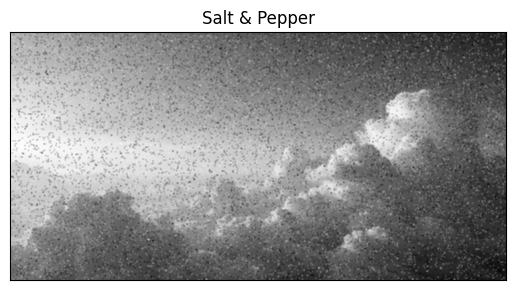

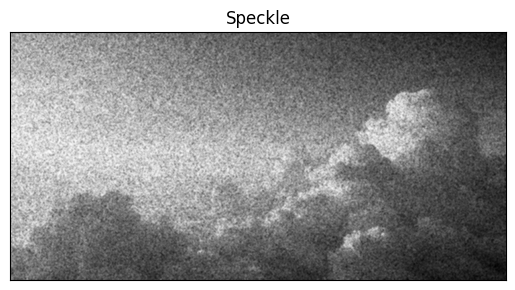

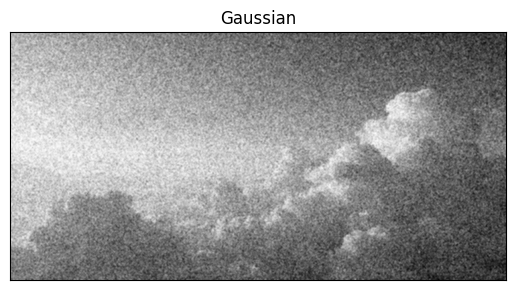

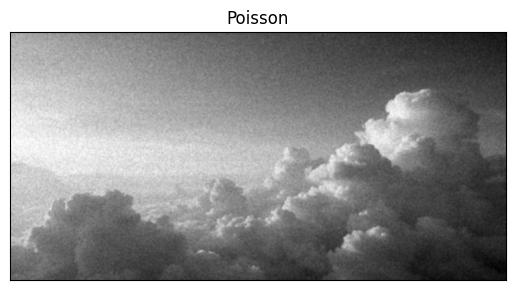

In [19]:
# TODO Place your solution here
# TODO Place your solution here
# TODO Place your solution here

# Dummy implementation, add a black image
w2 = np.array([[1, 1, 1],
               [1, 2, 1],
               [1, 1, 1]], dtype=np.float32) / 10.0

# Iw2 = [("None", np.zeros_like(I))]     
Iw2 = []
for img in Inoise:
  Iw2.append((img[0], cv.filter2D(img[1], -1, w2)))

# Show images
ShowImages(Iw2, 0)

### **2.3 Arithmetic mean filter**

This filter averages the pixel intensity value over the neighborhood using a mask with the same coefficients, for example, for a mask with the size $3 \times 3$ the coefficients are $1/9$, if $5 \times 5$ --- $1/25$. Thanks to this normalization, the value of the filtering result will be reduced to the original image intensities range. Graphically, the two-dimensional function describing the filter mask looks like a parallelepiped, so the name is used in English literature *box*-filter. Arithmetic averaging is achieved using the following formula:

Этот фильтр усредняет значение интенсивности пикселя по окрестности, используя маску с одинаковыми коэффициентами, например, для маски размером $3 \times 3$ коэффициенты равны $1/9$, если $5 \times 5$ — $1/25$. Благодаря такой нормализации значение результата фильтрации будет приведено к диапазону интенсивностей исходного изображения. Графически двумерная функция, описывающая маску фильтра, выглядит как параллелепипед, поэтому в англоязычной литературе используется название *box*-фильтр. Усреднение по арифметическому достигается с помощью следующей формулы:

$$I_{filtered}(x,y) = \dfrac{1}{m \cdot n} \sum_{i=0}^m \sum_{j=0}^n I(i,j)$$

where $I_{filtered}(x,y)$ is fht the value of the filtered image pixel intensity, $I(i,j)$ is the the value of the original image in the mask pixels intensities, $m$ and $n$ are the filter mask width and height respectively. This algorithm is effective for slightly noisy images. In OpenCV it can be executed by using the function `cv2.blur(I, (3, 3))` for $3 \times 3$ filter kernel.

где $I_{filtered}(x,y)$ — значение интенсивности пикселя отфильтрованного изображения, $I(i,j)$ — значение интенсивности исходного изображения в пикселях маски, $m$ и $n$ — ширина и высота маски фильтра соответственно. Этот алгоритм эффективен для слегка зашумленных изображений. В OpenCV его можно выполнить с помощью функции `cv2.blur(I, (3, 3))` для ядра фильтра $3 \times 3$.


In [ ]:
# Create a storage for the images filtered with arithmetic mean filter
Iblur = []
# Apply filter to all images and add them to an array for displaying
for img in Inoise:
  Iblur.append((img[0], cv.blur(img[1], (3, 3))))
# Show filtered images
ShowImages(Iblur, 0)

### **2.4 Geometric mean filter**

Geometric averaging is calculated using the formula:

Среднее геометрическое вычисляется по формуле:

$$I_{filtered}(x,y) = \left[\prod_{i=0}^{m}\prod_{j=0}^{n} I(i,j)\right]^{\dfrac{1}{m \cdot n}}$$

The effect of applying this filter is similar to the previous method, but individual objects in the original image are less distorted. The filter can be used to suppress high-pass additive noise with better statistical performance than an arithmetic averaging filter.

Эффект от применения этого фильтра аналогичен предыдущему методу, но отдельные объекты на исходном изображении искажаются меньше. Фильтр можно использовать для подавления высокочастотного аддитивного шума с лучшими статистическими характеристиками, чем фильтр среднего арифметического.


This filter can be easily implemented via arithmetic mean filter since $\prod_{i}x_i = e^{\sum_{i}\ln{}x_i}$, so

Этот фильтр можно легко реализовать через фильтр среднего арифметического, поскольку $\prod_{i}x_i = e^{\sum_{i}\ln{}x_i}$, таким образом

$$I_{filtered}(x,y) = \left[\prod_{i=0}^{m}\prod_{j=0}^{n} I(i,j)\right]^{\dfrac{1}{m \cdot n}} = \left[e^{\sum_{i=0}^{m}\sum_{j=0}^{n} \ln{I(i,j)}}\right]^{\dfrac{1}{m \cdot n}}$$

Let's implement it for a $5 \times 5$ kernel.

Давайте реализуем его для ядра $5 \times 5$.

In [ ]:
# Define a kernel
kernel = np.ones((5, 5)) / 25
# Create a storage for the images filtered with geometric mean filter
Igeom = []
# Apply filter to all images and add them to an array for displaying
for img in Inoise:
  Itmp = img[1].copy()
  if img[1].dtype == np.uint8:
    Itmp[Itmp == 0] = 1
    Ifilter = np.power(np.exp(cv.filter2D(np.log(Itmp).astype(np.float32), -1, kernel)), np.sum(kernel)).clip(0, 255).astype(np.uint8)
  else:
    Itmp[Itmp == 0] = sys.float_info.epsilon
    Ifilter = np.power(np.exp(cv.filter2D(np.log(Itmp).astype(np.float32), -1, kernel)), np.sum(kernel))
  Igeom.append((img[0], Ifilter))
# Show filtered images
ShowImages(Igeom, 0)

### **2.5 Harmonic mean filter**

The filter is based on the expression:

Фильтр основан на выражении:

$$I_{filtered}(x,y) = \dfrac{m \cdot n}{ \sum_{i=0}^m \sum_{j=0}^n \frac{1}{I(i,j)}}$$

The filter suppresses "*salt*" noise well and does not work with "*pepper*" noise.

Фильтр хорошо подавляет шум типа "*соль*" и не работает с шумом типа "*перец*".

Let's implement this filter.

At first, we need to create an image with borders, i.e., increase the image size not to think how to work with border items. As result image pixels will be shifted by the half of kernel, plus this gap will be filled with image border pixels. This is done by calling the `cv2.copyMakeBorder(I, ...)` function. It takes the following parameters: image, four gaps (top, bottom, left, right) and border type. We will use `cv2.BORDER_REPLICATE` to fill these gaps with border pixel values.

Next, we will use numpy matrix operations to calculate whole sums for the whole image at time. Don't forget that this filter works in floating point pixel values, so `uint8` images should be converted to floats and divided by $255$.

Давайте реализуем этот фильтр.

Сначала нам нужно создать изображение с границами, т.е. увеличить размер изображения, чтобы не думать о том, как работать с граничными элементами. В результате пиксели изображения будут смещены на половину ядра, плюс этот промежуток будет заполнен граничными пикселями изображения. Это делается вызовом функции `cv2.copyMakeBorder(I, ...)`. Она принимает следующие параметры: изображение, четыре отступа (сверху, снизу, слева, справа) и тип границы. Мы будем использовать `cv2.BORDER_REPLICATE`, чтобы заполнить эти промежутки значениями граничных пикселей.

Далее мы будем использовать операции с матрицами numpy для вычисления всех сумм для всего изображения сразу. Не забывайте, что этот фильтр работает со значениями пикселей с плавающей точкой, поэтому изображения `uint8` должны быть преобразованы в числа с плавающей точкой и разделены на $255$.

In [20]:
## Execute the harmonic mean filter
## @param[in] I An image to filter
## @param[in] kernel_size The size of the filter kernel
## @return Filtered image
def HarmonicMeanFilter(I, kernel_size):
  rows, cols = I.shape[0:2]

  # Filter parameters
  kernel = np.ones((kernel_size[0], kernel_size[1]))
  #kernel = kernel / kernel_size[0] / kernel_size[1]

  # Convert to float and make image with border
  if I.dtype == np.uint8:
    Icopy = I.astype(np.float32) / 255
  else:
    Icopy = I
  Icopy[Icopy == 0] = sys.float_info.epsilon
  Icopy = cv.copyMakeBorder(Icopy, 
                            (kernel_size[0] - 1) // 2, kernel_size[0] // 2, 
                            (kernel_size[1] - 1) // 2, kernel_size[1] // 2, 
                            cv.BORDER_REPLICATE)

  # Do filter
  Iout = np.zeros(I.shape, np.float32)
  for i in range(kernel_size[0]):
    for j in range(kernel_size[1]):
      Iout = Iout + kernel[i, j] / Icopy[i:i + rows, j:j + cols]
  Iout = np.sum(kernel) / Iout

  # Convert back to uint if needed
  if (I.dtype == np.uint8):
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)

  return Iout

Now we can apply it to our noisy images.

Теперь мы можем применить его к нашим зашумленным изображениям.

In [ ]:
# Create a storage for the images filtered with a harmonic mean filter
Ihmean = []
# Apply filter to all images and add them to an array for displaying
for img in Inoise:
  Ihmean.append((img[0], HarmonicMeanFilter(img[1], (5, 5))))
# Show filtered images
ShowImages(Ihmean, 0)

It can be seen that *pepper* noise got worse, but *salt* was cleaned. Let's try filtering *salt* only noise.

Видно, что шум типа *перец* стал хуже, но *соль* была очищена. Давайте попробуем отфильтровать шум только типа *соль*.

In [ ]:
# Add salt-type noise
Isalt = SaltAndPepper(I, 0.05, 1)
# Filter image with harmonic mean filter and show the result
ShowImages([("Salt only", Isalt), ("Harmonic mean filter", HarmonicMeanFilter(Isalt, (5, 5)))])

### **2.6 Contra harmonic mean filter**

The filter is based on the expression:

Фильтр основан на выражении:

$$I_{filtered}(x,y) = \dfrac{\sum_{i=0}^m \sum_{j=0}^n I(i,j)^{Q+1}}{\sum_{i=0}^m \sum_{j=0}^n I(i,j)^Q }$$

where $Q$ is the filter order. The contra harmonic filter is a generalization of the averaging filters and for $Q>0$ suppresses noises of the "*pepper*" type, and if $Q<0$ then noises of the "*salt*" type, however, it is not possible to remove white and black points at the same time. If $Q=0$ the filter turns into an arithmetic one, and if $Q=-1$ then to the harmonic one.

где $Q$ — порядок фильтра. Контргармонический фильтр является обобщением усредняющих фильтров и при $Q>0$ подавляет шумы типа "*перец*", а если $Q<0$, то шумы типа "*соль*", однако удалить одновременно белые и черные точки невозможно. Если $Q=0$, фильтр превращается в арифметический, а если $Q=-1$, то в гармонический.

Implementation of the contra harmonic mean filter is very similar to a harmonic one. The only difference is that now we have to calculate top and bottom parts for the whole image separately, and then divide them.

Реализация контргармонического среднего фильтра очень похожа на гармонический. Единственное отличие заключается в том, что теперь нам нужно отдельно вычислить верхнюю и нижнюю части для всего изображения, а затем разделить их.

##### **2.6.1 Self-work**

> **Self-work**
>
> Finish the implementation of the contra harmonic mean filter.
>
> **Самостоятельная работа**
>
> Завершите реализацию контргармонического среднего фильтра.


In [21]:
## Execute the contra harmonic mean filter
## @param[in] I An image to filter
## @param[in] kernel_size The size of the filter kernel
## @param[in] Q Filter parameter
## @return Filtered image
def ContraHarmonicMeanFilter(I, kernel_size, Q):
  rows, cols = I.shape[0:2]

  # Filter parameters
  kernel = np.ones((kernel_size[0], kernel_size[1]))
  kernel = kernel / kernel_size[0] / kernel_size[1]

  # Convert to float and make image with border
  if I.dtype == np.uint8:
    Icopy = I.astype(np.float32) / 255
  else:
    Icopy = I
  Icopy = cv.copyMakeBorder(Icopy, 
                            (kernel_size[0] - 1) // 2, kernel_size[0] // 2, 
                            (kernel_size[1] - 1) // 2, kernel_size[1] // 2, 
                            cv.BORDER_REPLICATE)

  # Calculate temporary matrices for I ** Q and I ** (Q + 1)
  Iout1 = np.zeros(I.shape, np.float32)
  Iout2 = np.zeros(I.shape, np.float32)
  for i in range(kernel_size[0]):
    for j in range(kernel_size[1]):
      Iout1 = Iout1 + (Icopy[i:i + rows, j:j + cols] + 1e-13) **(Q+1)
      Iout2 = Iout2 + (Icopy[i:i + rows, j:j + cols] + 1e-13) **(Q)
  # Calculate numerator and denominator for each pixel
  # Divide numerator by denominator
  Iout = Iout1 / (Iout2 + 1e-13)
  # Convert back to uint if needed
  if (I.dtype == np.uint8):
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)
  # And return the result
  return Iout


When filter implementation is finished we can apply it to our noisy images.

Когда реализация фильтра будет завершена, мы можем применить его к нашим зашумленным изображениям.

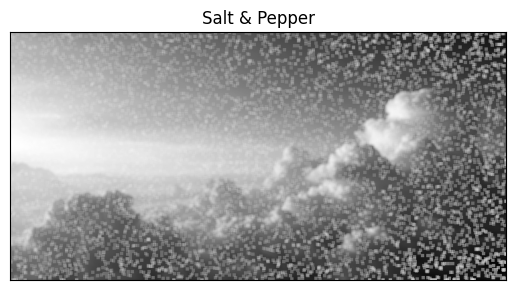

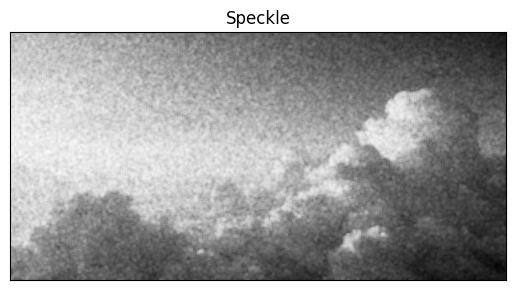

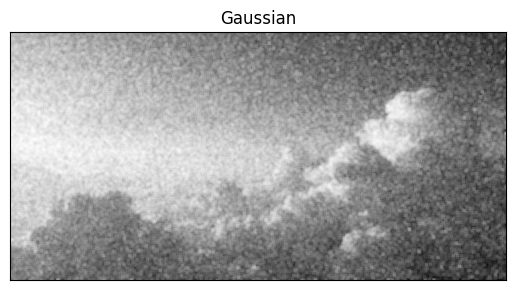

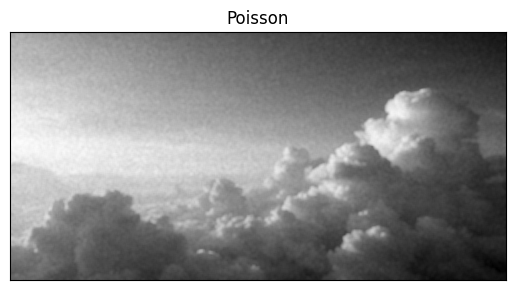

In [22]:
# Create a storage for the images filtered with contra harmonic mean filter
Ichmean = []
# Apply filter to all images and add them to an array for displaying
for img in Inoise:
  Ichmean.append((img[0], ContraHarmonicMeanFilter(img[1], (5, 5), 2)))
# Show filtered images
ShowImages(Ichmean, 0)

##### **2.6.2 Self-work**

> ***Self-work***
>
> Try different $Q$ parameter values and tell which works better with different noise types.
>
> ***Самостоятельная работа***
>
> Попробуйте различные значения параметра $Q$ и определите, какие из них лучше работают с разными типами шума.


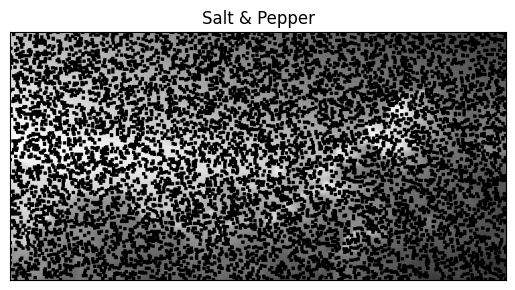

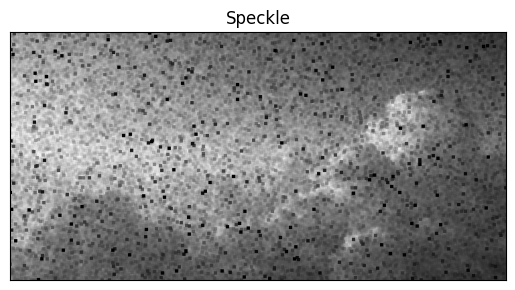

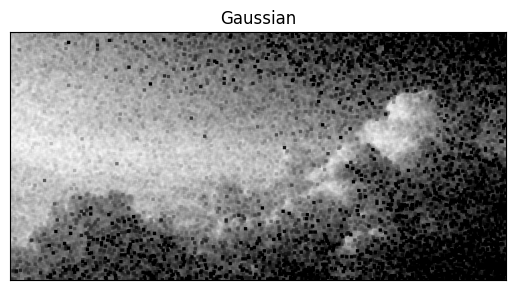

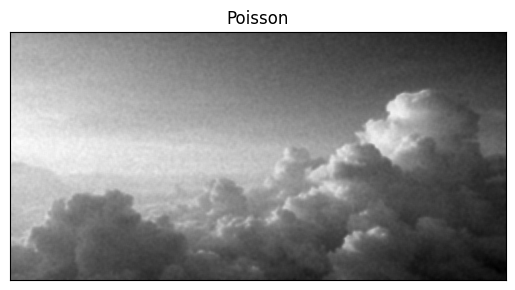

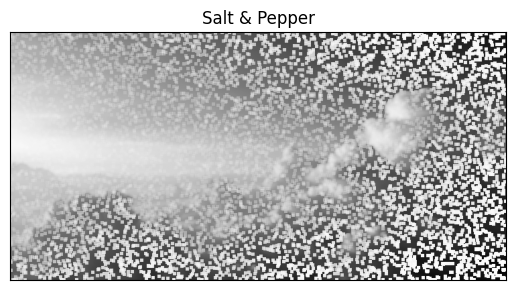

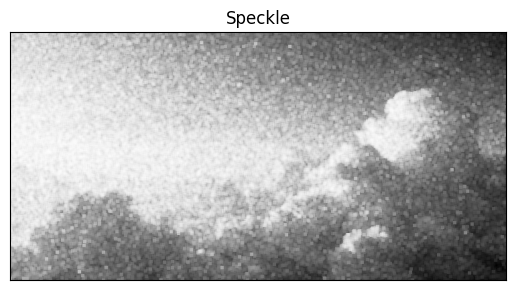

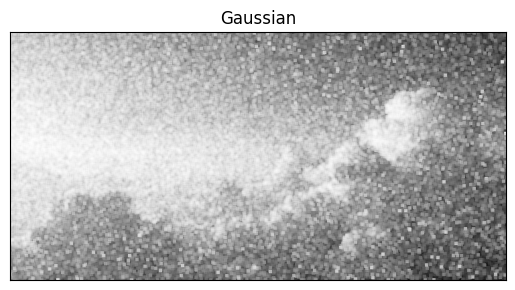

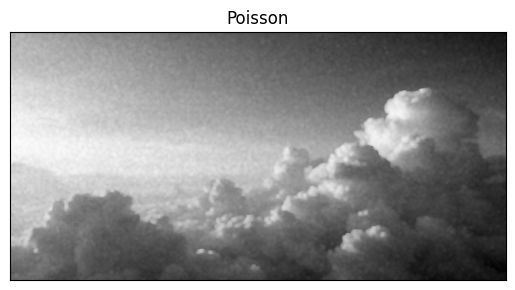

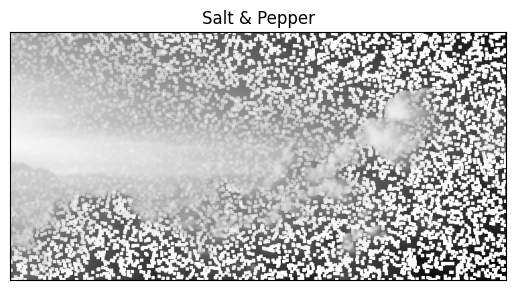

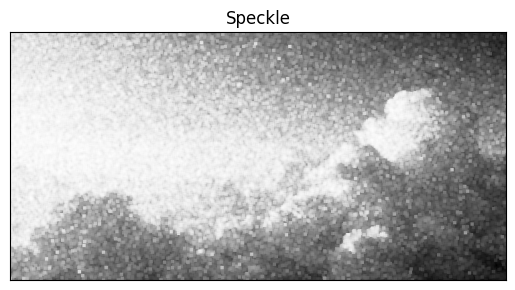

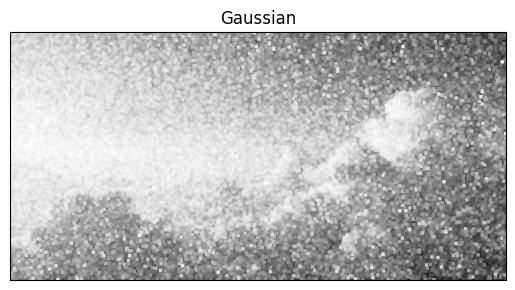

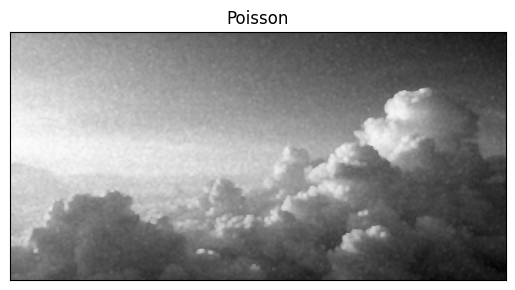

In [23]:
# TODO Place your solution here
# TODO Place your solution here
# TODO Place your solution here

Ichmean = []

for img in Inoise:
  Ichmean.append((img[0], ContraHarmonicMeanFilter(img[1], (5, 5), -2)))

ShowImages(Ichmean, 0)
Ichmean = []

for img in Inoise:
  Ichmean.append((img[0], ContraHarmonicMeanFilter(img[1], (5, 5), 5)))

ShowImages(Ichmean, 0)
Ichmean = []

for img in Inoise:
  Ichmean.append((img[0], ContraHarmonicMeanFilter(img[1], (5, 5), 7)))

ShowImages(Ichmean, 0)


### **2.7 Gaussian filter**

The pixels in the sliding window that are closer to the analyzed pixel should have a greater influence on the filtering result than the extreme ones. Therefore, the mask weight coefficients can be described by the bell-shaped Gaussian function. During images filtering, a two-dimensional Gaussian filter is used:

Пиксели в скользящем окне, которые находятся ближе к анализируемому пикселю, должны оказывать большее влияние на результат фильтрации, чем крайние. Поэтому весовые коэффициенты маски можно описать колоколообразной функцией Гаусса. При фильтрации изображений используется двумерный фильтр Гаусса:

$$G_{\sigma}=\dfrac{1}{2\pi\sigma^2}e^{-\frac{x^2+y^2}{2\sigma^2}}=\dfrac{1}{\sigma\sqrt{2\pi}}e^{\frac{-x^2}{2\sigma^2}}\cdot\dfrac{1}{\sigma\sqrt{2\pi}}e^{\frac{-y^2}{2\sigma^2}}$$

The larger the parameter $\sigma$, the more the image is blurred. Typically the filter radius $r=3\sigma$. In this case, the mask size $2r+1\times 2r+1$ and the matrix size is $6\sigma+1\times 6\sigma+1$. Outside this neighborhood, the values of the Gaussian function will be negligible.

Чем больше параметр $\sigma$, тем сильнее размывается изображение. Обычно радиус фильтра $r=3\sigma$. В этом случае размер маски $2r+1\times 2r+1$, а размер матрицы $6\sigma+1\times 6\sigma+1$. За пределами этой окрестности значения функции Гаусса будут пренебрежимо малы.

OpenCV provides a function for Gaussian filter called `cv2.GaussianBlur(I, ksize, sigmaX, borderType)`. The additional parameters are used to specify the kernel size as a tuple (e.g., `ksize = (5, 5)` for $5 \times 5$ kernel), $\sigma$ value and border type (we will use `cv2.BORDER_REPLICATE`).

Let's run it.

OpenCV предоставляет функцию для фильтра Гаусса под названием `cv2.GaussianBlur(I, ksize, sigmaX, borderType)`. Дополнительные параметры используются для указания размера ядра в виде кортежа (например, `ksize = (5, 5)` для ядра $5 \times 5$), значения $\sigma$ и типа границы (мы будем использовать `cv2.BORDER_REPLICATE`).

Давайте запустим его.

##### **2.7.1 Self-work**

> **Self-work**
>
> Run the Gaussian blur filter for noisy images. Use the $5 \times 5$ kernel and $\sigma = 1.3$. Which type of noise does this filter works better with?
>
> **Самостоятельная работа**
>
> Запустите фильтр размытия по Гауссу для зашумленных изображений. Используйте ядро $5 \times 5$ и $\sigma = 1.3$. С каким типом шума этот фильтр работает лучше?


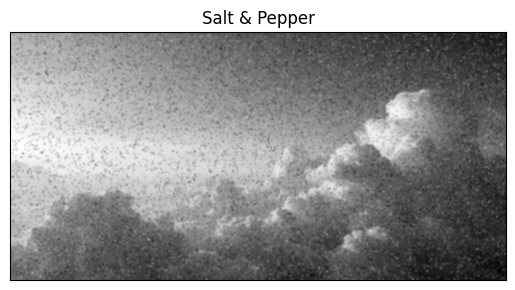

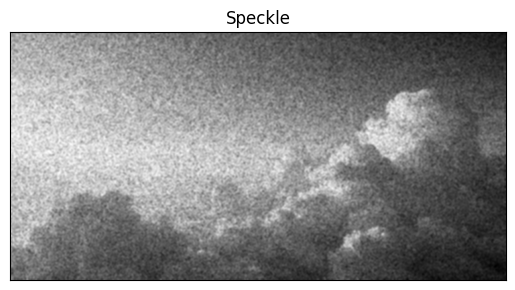

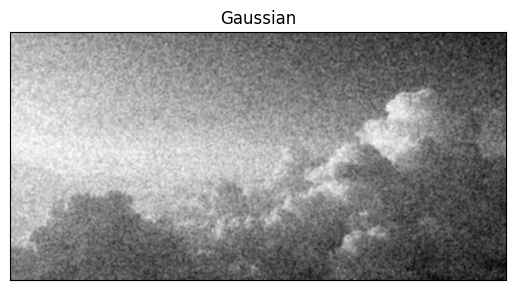

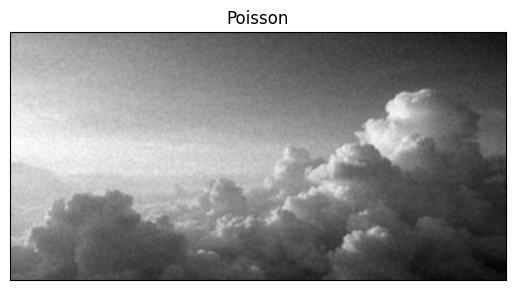

In [24]:
# Create a storage for the images filtered with a Gaussian filter
Igaussblur = []

# TODO Place your solution here
for img in Inoise:
  Igaussblur.append((img[0], cv.GaussianBlur(img[1], (5, 5), 1.3)))

ShowImages(Igaussblur, 0)

# TODO Place your solution here

## **Task 3. Nonlinear filtering**

*Process the distorted images obtained in the first point with median, weighted median, rank and Wiener filtering for different sizes of the mask and its coefficients.*

*Optional: Implement adaptive median filtering.*

*Обработайте искаженные изображения, полученные в первом пункте, с помощью медианной, взвешенной медианной, ранговой и винеровской фильтрации для различных размеров маски и ее коэффициентов.*

*Необязательно: Реализуйте адаптивную медианную фильтрацию.*

Low-pass filters are linear and are optimal when there is a normal distribution of noise in the digital image. Linear filters locally average impulse noise, smoothing images. To eliminate impulse noise, it is better to use non-linear filters, for example, *median* filters.

Фильтры нижних частот являются линейными и оптимальны при нормальном распределении шума в цифровом изображении. Линейные фильтры локально усредняют импульсный шум, сглаживая изображения. Для устранения импульсного шума лучше использовать нелинейные фильтры, например, *медианные* фильтры.

### **3.1 Median filter**

The classical median filter uses a mask with unit coefficients. An arbitrary window shape can be set using zero coefficients. The pixel intensities in the window are represented as a column vector and sorted in ascending order. The filtered pixel is assigned the median (mean) intensity value in the series. The median element number after sorting can be calculated by the formula $n=\frac{N+1}{2}$, where $N$ is the number of pixels involved in sorting. When using OpenCV, the median filter can be executed by calling `cv2.medianBlur(I, ksize)` function.

Классический медианный фильтр использует маску с единичными коэффициентами. Произвольную форму окна можно задать с помощью нулевых коэффициентов. Значения интенсивностей пикселей в окне представляются в виде вектора-столбца и сортируются по возрастанию. Отфильтрованному пикселю присваивается медианное (среднее) значение интенсивности в ряду. Номер медианного элемента после сортировки можно вычислить по формуле $n=\frac{N+1}{2}$, где $N$ — количество пикселей, участвующих в сортировке. При использовании OpenCV медианный фильтр можно выполнить, вызвав функцию `cv2.medianBlur(I, ksize)`.

| ![Median filter](images/median.png "Median Filter") | 
|:--:| 
| *Median filter* |
| *Медианный фильтр* |


#### **3.1.1 Self-work**

> ***Self-work*** 
>
> Run the median filter for noisy images. Which type of noise does this filter works better with?
>
> ***Самостоятельная работа***
>
> Запустите медианный фильтр для зашумленных изображений. С каким типом шума этот фильтр работает лучше?


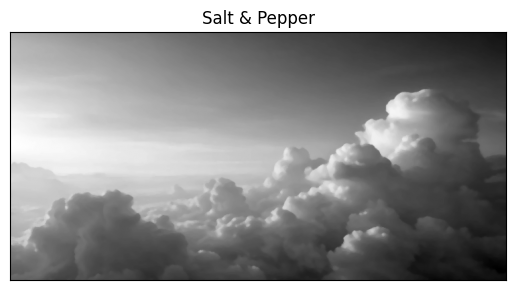

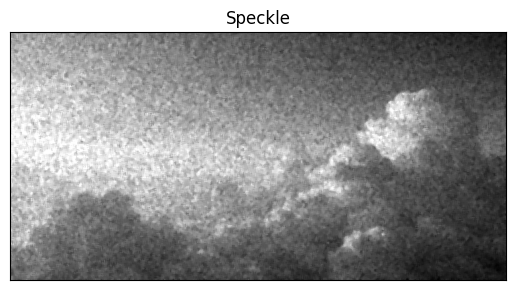

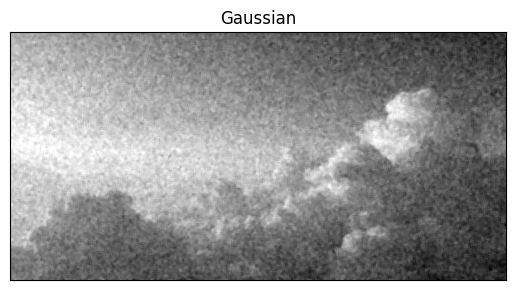

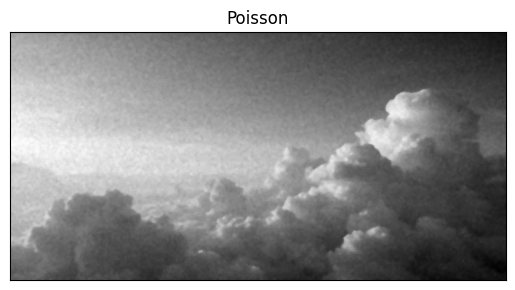

In [25]:
# Create a storage for the images filtered with a median filter
Imedian = []

# TODO Place your solution here
for img in Inoise:
  Imedian.append((img[0], cv.medianBlur(img[1], 5)))

ShowImages(Imedian, 0)

### **3.2 Weighted median filter**

In this median filtering modification in the mask, weights are used (numbers $2, 3$ etc.) to reflect more influence on the filtering result of pixels located closer to the element to be filtered. Each item is added the giver number of times to the array before sorting. Median filtering qualitatively removes impulse noise, and also does not introduce new intensity values in grayscale images. Increasing the size of the window increases the filter noise-canceling ability, but the objects outlines begin to distort. OpenCV does not profive weighted median filter, but it can be implemented.

В этой модификации медианной фильтрации в маске используются веса (числа $2, 3$ и т.д.), чтобы отразить большее влияние на результат фильтрации пикселей, расположенных ближе к фильтруемому элементу. Каждый элемент добавляется заданное количество раз в массив перед сортировкой. Медианная фильтрация качественно удаляет импульсный шум, а также не вносит новых значений интенсивности в полутоновые изображения. Увеличение размера окна повышает способность фильтра подавлять шум, но контуры объектов начинают искажаться. OpenCV не предоставляет взвешенный медианный фильтр, но его можно реализовать.


In [26]:
## Weighted median filter
## @param[in] I An image to filter
## @param[in] weights Weights kernel
## @return The filtered image
def WightedMedianFilter(I, weights):
  rows, cols = I.shape[0:2]
  weights = weights.astype(np.uint16)
  kernel_size = weights.shape
  rank = int(weights.sum() // 2)

  # Convert to float and make image with border
  if I.dtype == np.uint8:
    Icopy = I.astype(np.float32) / 255
  else:
    Icopy = I
  Icopy = cv.copyMakeBorder(Icopy, 
                            (kernel_size[0] - 1) // 2, kernel_size[0] // 2, 
                            (kernel_size[1] - 1) // 2, kernel_size[1] // 2, 
                            cv.BORDER_REPLICATE)

  # Fill arrays for each kernel item
  Ilayers = np.zeros(I.shape + (weights.sum(), ), dtype = np.float32)
  if I.ndim == 2:
    n = 0
    for i in range(kernel_size[0]):
      for j in range(kernel_size[1]):
          for k in range(weights[i, j]):
            Ilayers[:, :, n] = Icopy[i:i + rows, j:j + cols]
            n += 1
  else:
    n = 0
    for i in range(kernel_size[0]):
      for j in range(kernel_size[1]):
        for k in range(weights[i, j]):
          Ilayers[:, :, :, n] = Icopy[i:i + rows, j:j + cols, :]
          n += 1

  # Sort
  Ilayers.sort()

  # And select one with rank
  if I.ndim == 2:
    Iout = Ilayers[:, :, rank]
  else:
    Iout = Ilayers[:, :, :, rank]

  # Convert back to uint if needed
  if (I.dtype == np.uint8):
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)

  return Iout

Let's run this filter doubling the weight of the central point.

Давайте запустим этот фильтр, удвоив вес центральной точки.

In [ ]:
# Define weights
weights = np.ones((3, 3))
weights[1, 1] = 2
# Create a storage for the images filtered with a weighted median filter
Iwmedian = []
# Apply filter to all images and add them to an array for displaying
for img in Inoise:
  Iwmedian.append((img[0], WightedMedianFilter(img[1], weights)))
# Show filtered images
ShowImages(Iwmedian, 0)

### **3.3 Rank filter**

A median filtering generalization is a *rank filter* of order $r$ which selects a pixel with the given number from the resulting column vector of mask elements $r\in[1,N]$, which will be the result of filtering.

- If the number of pixels in the window $N$ is odd and $r=\frac{N+1}{2}$, then the rank filter is *median*.
- If $r=1$, the filter selects the lowest intensity value and is called *$min$-filter*.
- If $r=N$, the filter selects the maximum intensity value and is called *$max$-filter*.

Sometimes rank is written as a percentage, for example, for *$min$-filter* rank is $0%$, median filter is $50%$, *$max$-filter* is $100%$.

Обобщением медианной фильтрации является *ранговый фильтр* порядка $r$, который выбирает пиксель с заданным номером из результирующего вектора-столбца элементов маски $r\in[1,N]$, который и будет результатом фильтрации.

- Если количество пикселей в окне $N$ нечетно и $r=\frac{N+1}{2}$, то ранговый фильтр является *медианным*.
- Если $r=1$, фильтр выбирает наименьшее значение интенсивности и называется *$min$-фильтром*.
- Если $r=N$, фильтр выбирает максимальное значение интенсивности и называется *$max$-фильтром*.

Иногда ранг записывают в процентах, например, для *$min$-фильтра* ранг составляет $0%$, медианного фильтра — $50%$, *$max$-фильтра* — $100%$.


It can be noted that when implementing the weighted median filter we already had the `rank` variable which was used to find the median in the varying length array. We can make it a filter parameter to make it the weighted rank filter.

Можно заметить, что при реализации взвешенного медианного фильтра у нас уже была переменная `rank`, которая использовалась для поиска медианы в массиве переменной длины. Мы можем сделать ее параметром фильтра, чтобы превратить его во взвешенный ранговый фильтр.

In [27]:
## Rank filter
## @param[in] I An image to filter
## @param[in] weights Weights kernel
## @param[in] rank The rank to use
## @return The filtered image
def WeightedRankFilter(I, weights, rank):
  rows, cols = I.shape[0:2]
  weights = weights.astype(np.uint16)
  kernel_size = weights.shape

  # Convert to float and make image with border
  if I.dtype == np.uint8:
    Icopy = I.astype(np.float32) / 255
  else:
    Icopy = I
  Icopy = cv.copyMakeBorder(Icopy, 
                            (kernel_size[0] - 1) // 2, kernel_size[0] // 2, 
                            (kernel_size[1] - 1) // 2, kernel_size[1] // 2, 
                            cv.BORDER_REPLICATE)

  # Fill arrays for each kernel item
  Ilayers = np.zeros(I.shape + (weights.sum(), ), dtype = np.float32)
  if I.ndim == 2:
    n = 0
    for i in range(kernel_size[0]):
      for j in range(kernel_size[1]):
          for k in range(weights[i, j]):
            Ilayers[:, :, n] = Icopy[i:i + rows, j:j + cols]
            n += 1
  else:
    n = 0
    for i in range(kernel_size[0]):
      for j in range(kernel_size[1]):
        for k in range(weights[i, j]):
          Ilayers[:, :, :, n] = Icopy[i:i + rows, j:j + cols, :]
          n += 1

  # Sort
  Ilayers.sort()

  # And select one with rank
  if I.ndim == 2:
    Iout = Ilayers[:, :, rank]
  else:
    Iout = Ilayers[:, :, :, rank]

  # Convert back to uint if needed
  if (I.dtype == np.uint8):
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)

  return Iout

Of course a more simple and fast modification can be used to get only a rank filter.

Конечно, можно использовать более простую и быструю модификацию, чтобы получить только ранговый фильтр.

In [28]:
## Rank filter
## @param[in] I An image to filter
## @param[in] kernel_size The filter kernel size
## @param[in] rank The rank to use
## @return The filtered image
def RankFilter(I, kernel_size, rank):
  rows, cols = I.shape[0:2]

  # Convert to float and make image with border
  if I.dtype == np.uint8:
    Icopy = I.astype(np.float32) / 255
  else:
    Icopy = I
  Icopy = cv.copyMakeBorder(Icopy, 
                            (kernel_size[0] - 1) // 2, kernel_size[0] // 2, 
                            (kernel_size[1] - 1) // 2, kernel_size[1] // 2, 
                            cv.BORDER_REPLICATE)

  # Fill arrays for each kernel item
  Ilayers = np.zeros(I.shape + (kernel_size[0] * kernel_size[1], ), dtype = np.float32)
  if I.ndim == 2:
    for i in range(kernel_size[0]):
      for j in range(kernel_size[1]):
          Ilayers[:, :, i * kernel_size[1] + j] = Icopy[i:i + rows, j:j + cols]
  else:
    for i in range(kernel_size[0]):
      for j in range(kernel_size[1]):
        Ilayers[:, :, :, i * kernel_size[1] + j] = Icopy[i:i + rows, j:j + cols, :]

  # Sort
  Ilayers.sort()

  # And select one with rank
  if I.ndim == 2:
    Iout = Ilayers[:, :, rank]
  else:
    Iout = Ilayers[:, :, :, rank]

  # Convert back to uint if needed
  if (I.dtype == np.uint8):
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)

  return Iout

Let's run this filter and check the results.

Давайте запустим этот фильтр и проверим результаты.

#### **3.3.1 Self-work**

> ***Self-work***
>
> Run the rank filter for $min$ and $max$ parameter values with all noise types.
>
> ***Самостоятельная работа***
>
> Запустите ранговый фильтр для параметров $min$ и $max$ для всех типов шума.


Run the $min$ rank filter.

Запустите $min$ ранговый фильтр.

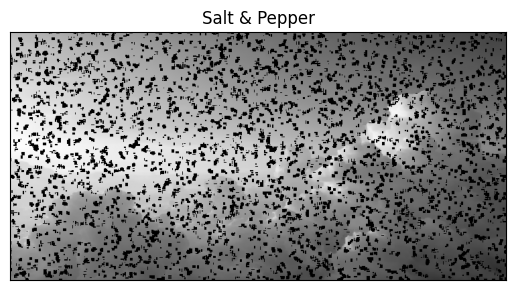

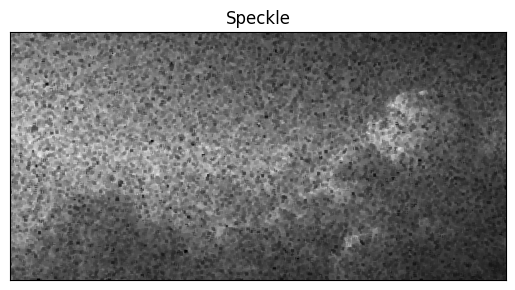

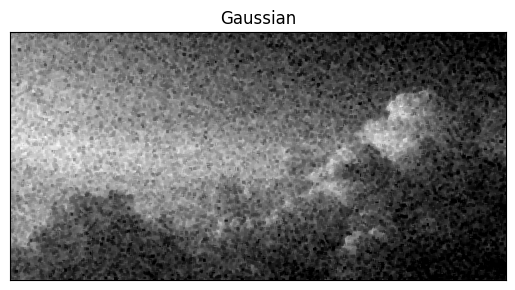

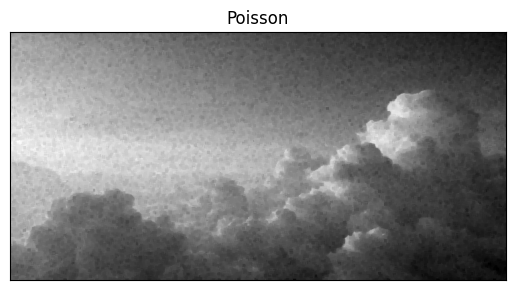

In [29]:
# Create a storage for the images filtered with a min rank filter
Irank_min = []

# TODO Place your solution here
for img in Inoise:
  # TODO Place your solution here
  Irank_min.append((img[0], RankFilter(img[1], (5, 5), 1)))
# Show filtered images
ShowImages(Irank_min, 0)

Run the $max$ rank filter.

Запустите $max$ ранговый фильтр.

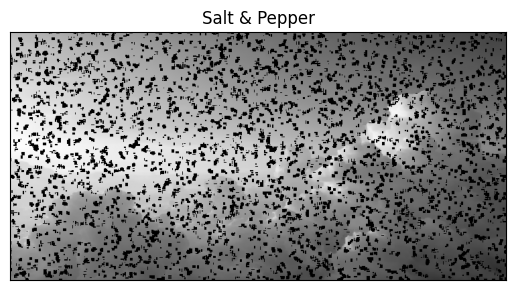

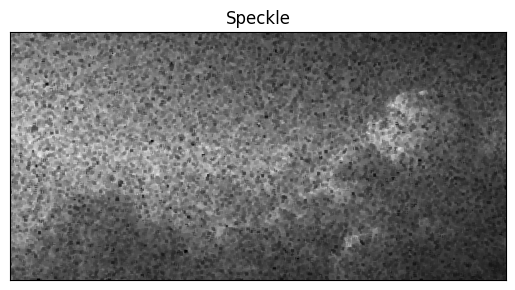

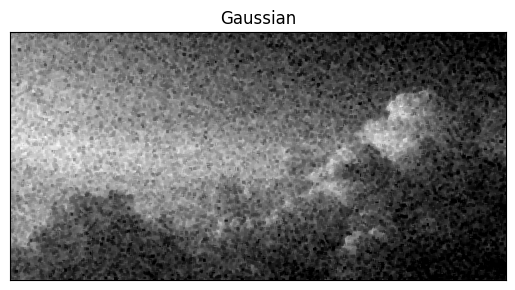

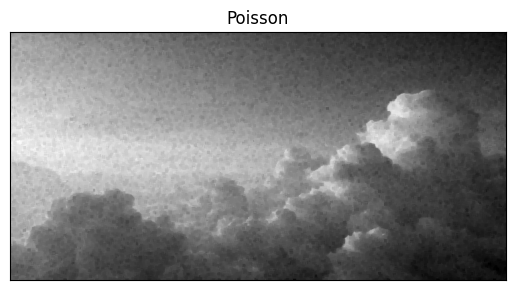

In [30]:
# Create a storage for the images filtered with a max rank filter
Irank_max = []

# TODO Place your solution here
for img in Inoise:
  # TODO Place your solution here
  Irank_max.append((img[0], RankFilter(img[1], (5, 5), 1)))
# Show filtered images
ShowImages(Irank_max, 0)
# TODO Place your solution here
# TODO Place your solution here
# TODO Place your solution here


### **3.4 Adaptive median filter**

In this filter modification, a sliding window of size $s\times s$ adaptively increases depending on the filtering result. Let us denote by $z_{min}$, $z_{max}$, $z_{med}$ minimum, maximum and median values of intensities in the window, $z_{i,j}$ is the pixel intensity value with coordinates $(i,j)$, $s_{max}$ is the maximum allowed window size. The adaptive median filtering algorithm consists of the following steps:

В этой модификации фильтра скользящее окно размером $s\times s$ адаптивно увеличивается в зависимости от результата фильтрации. Обозначим через $z_{min}$, $z_{max}$, $z_{med}$ минимальное, максимальное и медианное значения интенсивностей в окне, $z_{i,j}$ — значение интенсивности пикселя с координатами $(i,j)$, $s_{max}$ — максимально допустимый размер окна. Алгоритм адаптивной медианной фильтрации состоит из следующих шагов:

1. Calculating values $z_{min}$, $z_{max}$, $z_{med}$, $A_1=z_{med}-z_{min}$, $A_2=z_{med}-z_{max}$ of the pixel $(i,j)$ in the given window. 
	1. If $A_1>0$ and $A_2<0$, go to step 2. Otherwise, increase the window size.
	2. If the current window size $s$ is less than maximum allowed (if $s\leqslant s_{max}$), repeat step 1. 
	3. Otherwise, the filtering result is $z_{i,j}$.
2. Calculating values $B_1=z_{i,j}-z_{min}$, $B_2=z_{i,j}-z_{max}$.
	1. If $B_1>0$ and $B_2<0$, the filtering result is $z_{i,j}$. 
	2. Otherwise, the filtering result is $z_{med}$.
3. Change coordinates $(i,j)$.
	1. If the image limit is not reached, go to step 1. 
	2. Otherwise, the filtering is over.

1. Вычисление значений $z_{min}$, $z_{max}$, $z_{med}$, $A_1=z_{med}-z_{min}$, $A_2=z_{med}-z_{max}$ для пикселя $(i,j)$ в заданном окне.
    1. Если $A_1>0$ и $A_2<0$, перейти к шагу 2. В противном случае увеличить размер окна.
    2. Если текущий размер окна $s$ меньше максимально допустимого (если $s\leqslant s_{max}$), повторить шаг 1.
    3. В противном случае результатом фильтрации является $z_{i,j}$.
2. Вычисление значений $B_1=z_{i,j}-z_{min}$, $B_2=z_{i,j}-z_{max}$.
    1. Если $B_1>0$ и $B_2<0$, результатом фильтрации является $z_{i,j}$.
    2. В противном случае результатом фильтрации является $z_{med}$.
3. Изменение координат $(i,j)$.
    1. Если предел изображения не достигнут, перейти к шагу 1.
    2. В противном случае фильтрация завершена.

The main idea is to increase the window size until the algorithm finds a median value that is not impulse noise, or until it reaches the maximum window size. In the latter case, the algorithm will return the value $z_{i,j}$.

Основная идея заключается в увеличении размера окна до тех пор, пока алгоритм не найдет медианное значение, которое не является импульсным шумом, или пока не будет достигнут максимальный размер окна. В последнем случае алгоритм вернет значение $z_{i,j}$.


#### **3.4.1 Self-work (Optional)**

> ***Self-work*** *(Optional)*
>
> *Implement the adaptive median filter and run it with different noise types. Your implementation should work both with grayscale images (image matrix has 2 dimensions) and BGR images (image matrix has 3 dimensions).*
>
> ***Самостоятельная работа*** *(Необязательно)*
>
> *Реализуйте адаптивный медианный фильтр и запустите его для различных типов шума. Ваша реализация должна работать как с полутоновыми изображениями (матрица изображения имеет 2 измерения), так и с BGR-изображениями (матрица изображения имеет 3 измерения).*


In [31]:
## Adaptive median filter
## @param[in] I An image to filter
## @param[in] max_kernel_size The maximum filter kernel size
## @return The filtered image
def AdaptiveMedianFilter(I, max_kernel_size):
    if len(I.shape) == 3:
        Iout = np.zeros_like(I)
        for channel in range(I.shape[2]):
            Iout[:,:,channel] = AdaptiveMedianFilter(I[:,:,channel], max_kernel_size)
        return Iout
    
    rows, cols = I.shape
    Iout = np.zeros_like(I)
    Icopy = I.astype(np.float32)
    
    for i in range(rows):
        for j in range(cols):
            kernel_size = 3
            while kernel_size <= max_kernel_size:
                half = kernel_size // 2
                
                i_min = max(0, i - half)
                i_max = min(rows, i + half + 1)
                j_min = max(0, j - half)
                j_max = min(cols, j + half + 1)
                
                window = Icopy[i_min:i_max, j_min:j_max]
                
                z_min = np.min(window)
                z_max = np.max(window)
                z_med = np.median(window)
                
                A1 = z_med - z_min
                A2 = z_med - z_max
                
                if A1 > 0 and A2 < 0:
                    B1 = Icopy[i, j] - z_min
                    B2 = Icopy[i, j] - z_max
                    
                    if B1 > 0 and B2 < 0:
                        Iout[i, j] = Icopy[i, j]
                    else:
                        Iout[i, j] = z_med
                    break
                else:
                    kernel_size += 2
                    if kernel_size > max_kernel_size:
                        Iout[i, j] = Icopy[i, j]
    
    if I.dtype == np.uint8:
        Iout = Iout.astype(np.uint8)
    
    return Iout


Now run the adaptive median filter for all noise types. Compare the results.

Теперь запустите адаптивный медианный фильтр для всех типов шума. Сравните результаты.

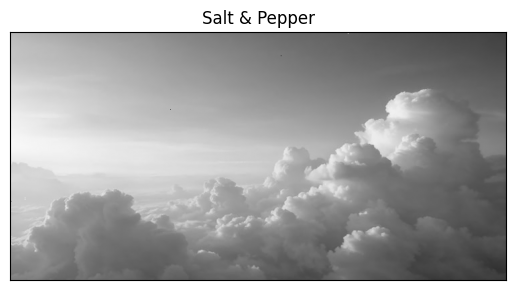

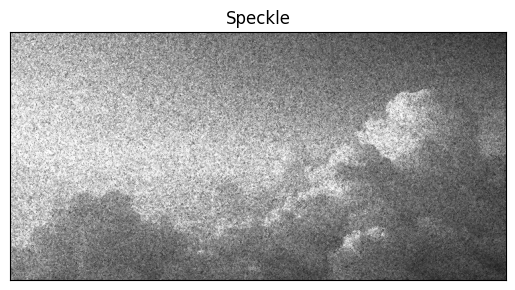

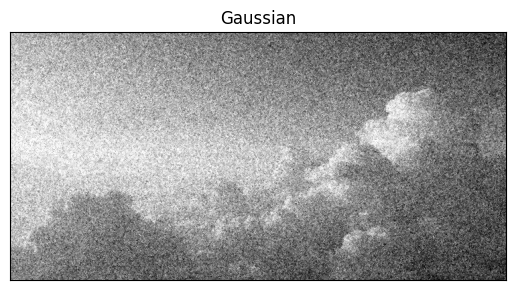

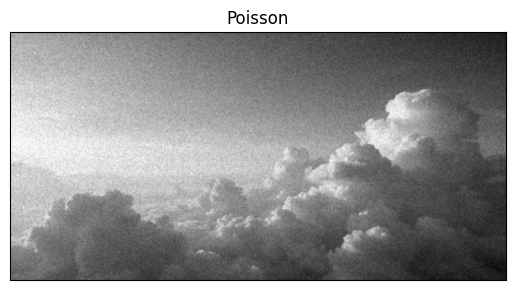

In [32]:
# Create a storage for the images filtered with an adaptive median filter
Iadaptive_med = []
# Apply filter to all images and add them to an array for displaying
for img in Inoise:
  Iadaptive_med.append((img[0], AdaptiveMedianFilter(img[1], 9)))
# Show filtered images
ShowImages(Iadaptive_med, 0)

### **3.5 Wiener filter**

Weiner filter uses Wiener's pixel-adaptive method based on statistics estimated from the local neighborhood of the each pixel.

Фильтр Винера использует адаптивный к пикселям метод Винера, основанный на статистике, оцененной из локальной окрестности каждого пикселя.

$$\mu=\dfrac{1}{n\cdot m}  \sum_{i=0}^{m}\sum_{j=0}^{n} I(i,j)$$

$$\sigma^2=\dfrac{1}{n\cdot m}  \sum_{i=0}^{m}\sum_{j=0}^{n} I^2(i,j)-\mu^2$$

$$I_{new}(x,y)=\mu+\dfrac{\sigma^2-v^2}{\sigma^2}\left(I(x,y)-\mu\right)$$

Where $\mu$ is the average in the neighborhood, $\sigma^2$ is the variance, and $v^2$ is the noise variance.

Где $\mu$ — среднее значение в окрестности, $\sigma^2$ — дисперсия, а $v^2$ — дисперсия шума.

OpenCV does not provide an implementation for this filter, but it can be easily implemented.

OpenCV не предоставляет реализацию этого фильтра, но его можно легко реализовать.

In [33]:
## The Weiner filter
## @param[in] img_noisy An image to filter
## @param[in] kernel Filter kernel
def WeinerFilter(I, kernel):
  rows, cols = I.shape[0:2]

  # Convert to float32
  if I.dtype == np.uint8:
    Iout = I.astype(np.float32) / 255
  else:
    Iout = np.copy(I)

  kernel_size = kernel.shape

  # Convert to float and make image with border
  if I.dtype == np.uint8:
    Icopy = I.astype(np.float32) / 255
  else:
    Icopy = I
  Icopy = cv.copyMakeBorder(Icopy, 
                            (kernel_size[0] - 1) // 2, kernel_size[0] // 2, 
                            (kernel_size[1] - 1) // 2, kernel_size[1] // 2, 
                            cv.BORDER_REPLICATE)

  # Split into layers
  bgr_planes = cv.split(Icopy)
  bgr_planes_2 = []

  kernel_power = np.power(kernel, 2)

  # For all layers
  for plane in bgr_planes:
    # Calculate temporary matrices for I ** 2
    plane_power = np.power(plane, 2)
    
    m = np.zeros(I.shape[0:2], np.float32)
    q = np.zeros(I.shape[0:2], np.float32)
    
    # Calculate variance values
    for i in range(kernel_size[0]):
      for j in range(kernel_size[1]):
        m = m + kernel[i, j] * plane[i:i + rows, j:j + cols]
        q = q + kernel_power[i, j] * plane_power[i:i + rows, j:j + cols]
    m = m / np.sum(kernel)
    q = q / np.sum(kernel)
    q = q - m * m
    
    # Calculate noise as an average variance
    v = np.sum(q) / I.size
    
    # Do filter
    plane_2 = plane[(kernel_size[0] - 1) // 2:(kernel_size[0] - 1) // 2 + rows, 
      (kernel_size[1] - 1) // 2:(kernel_size[1] - 1) // 2 + cols]
    plane_2 = np.where(q < v, m, (plane_2 - m) * (1 - v / q) + m)
    bgr_planes_2.append(plane_2)

  # Merge image back  
  Iout = cv.merge(bgr_planes_2)

  # Convert back to uint if needed
  if (I.dtype == np.uint8):
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)

  return Iout

#### **3.5.1 Self-work**

> ***Self-work***
>
> Run the Weiner filter with all of our noisy images. Use the $5 \times 5$ kernel filled with $1$.
>
> ***Самостоятельная работа***
>
> Запустите фильтр Винера для всех наших зашумленных изображений. Используйте ядро $5 \times 5$, заполненное $1$.


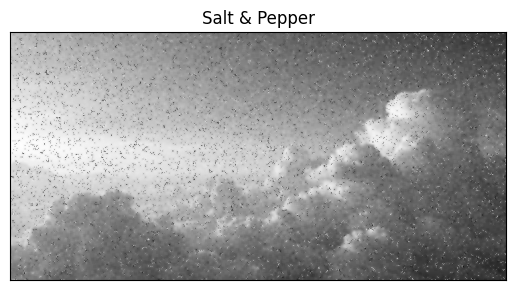

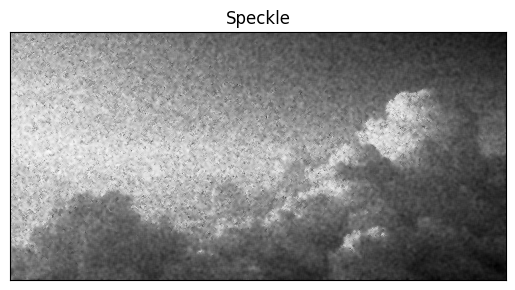

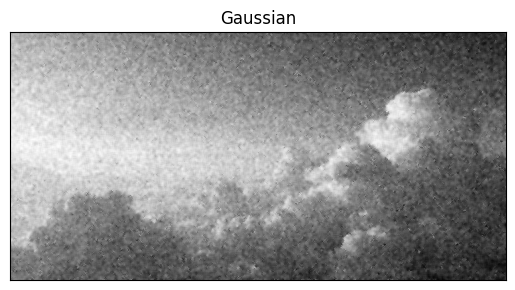

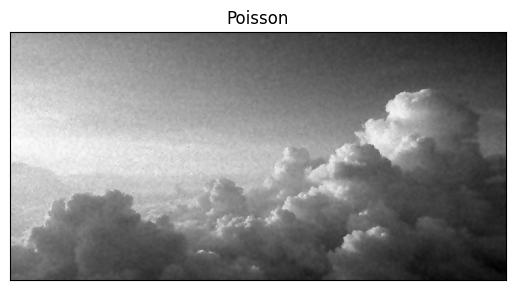

In [34]:
# Create a storage for the images filtered with a Weiner filter
Iweiner = []
kernel = np.ones((5, 5))
# TODO Place your solution here
for img in Inoise:
  # TODO Place your solution here
  Iweiner.append((img[0], WeinerFilter(img[1], kernel)))
# Show filtered images

ShowImages(Iweiner, 0)
# TODO Place your solution here
# TODO Place your solution here
# TODO Place your solution here


## **Task 4. High-pass filtering**

*Select source image. Detect edges with Roberts, Prewitt, Sobel, Laplace filters, Canny algorithm.*

*Выберите исходное изображение. Обнаружьте границы с помощью фильтров Робертса, Прюитта, Собеля, Лапласа, алгоритма Кэнни.*

High-pass spatial filters enhance high-pass components (areas of strong intensity variation) and attenuate low-pass components of the image. They are used to highlight intensity differences and define edges (contours) in images. As a result of applying high-pass filters, the image is sharpened.

Пространственные фильтры верхних частот усиливают высокочастотные компоненты (области сильного изменения интенсивности) и ослабляют низкочастотные компоненты изображения. Они используются для выделения перепадов интенсивности и определения границ (контуров) на изображениях. В результате применения фильтров верхних частот изображение становится более резким.

| ![High-pass filtering](images/high-pass.png "High-pass Filter") | 
|:--:| 
| *Intensity function and its first derivative, the maximum of the derivative corresponds to the edge* |
| *Функция интенсивности и ее первая производная, максимум производной соответствует границе* |

High-pass filters approximate the computation of directional derivatives, while the increment of the argument $\Delta x$ is taken equal to 1 or 2. The main distinctive features are:

- filter mask coefficients can take negative values;
- the sum of all coefficients is zero.

Фильтры верхних частот аппроксимируют вычисление производных по направлениям, при этом приращение аргумента $\Delta x$ принимается равным 1 или 2. Основные отличительные особенности:

- коэффициенты маски фильтра могут принимать отрицательные значения;
- сумма всех коэффициентов равна нулю.

### **4.1 Roberts filter**

The Roberts filter works with the minimum dimensionality mask allowed for the derivative calculation $2 \times 2$, therefore it is fast and quite efficient. Possible options for masks for finding the gradient along the axes $Ox$ and $Oy$:

Фильтр Робертса работает с маской минимально возможной размерности для вычисления производной $2 \times 2$, поэтому он быстр и достаточно эффективен. Возможные варианты масок для нахождения градиента по осям $Ox$ и $Oy$:

$$
	G_x = 
	\begin{bmatrix}
		1 & -1 \\
		0 & 0
	\end{bmatrix},
	G_y =
	\begin{bmatrix}
		1 & 0 \\
		-1 & 0
	\end{bmatrix},
$$

or

или

$$
	G_x = 
	\begin{bmatrix}
		1 & 0 \\
		0 & -1
	\end{bmatrix},
	G_y =
	\begin{bmatrix}
		0 & 1 \\
		-1 & 0
	\end{bmatrix}.
$$

As a result of applying the Roberts differential operator, we obtain an estimate of the gradient in the directions $G_x$ and $G_y$. The all edge detectors gradient modulus can be calculated by the formula $G=\sqrt{G_x^2+G_y^2}=|G_x|+|G_y|$, and gradient direction by the formula $\arctan{ \left(\dfrac{G_y}{G_x}\right) }$. 

В результате применения дифференциального оператора Робертса мы получаем оценку градиента по направлениям $G_x$ и $G_y$. Модуль градиента для всех детекторов границ можно вычислить по формуле $G=\sqrt{G_x^2+G_y^2}=|G_x|+|G_y|$, а направление градиента — по формуле $\arctan{ \left(\dfrac{G_y}{G_x}\right) }$.


In OpenCV it is implemented by calling `cv2.filter2D()` function with two matrices $G_x$ and $G_y$ and then calculating their square mean by `cv2.magnitude()` function.

В OpenCV это реализуется вызовом функции `cv2.filter2D()` с двумя матрицами $G_x$ и $G_y$, а затем вычислением их среднеквадратичного значения с помощью функции `cv2.magnitude()`.

In [35]:
## The Roberts filter
## @param[in] I An image to filter
## @return The filtered image
def RobertsFilter(I):
  # Convert to float
  if I.dtype == np.uint8:
    Iout = I.astype(np.float32) / 255
  else:
    Iout = np.copy(I)

  # Define kernels for X and Y
  kernel_x = np.array([[1, -1], [ 0, 0]])
  kernel_y = np.array([[1,  0], [-1, 0]])

  # Perform convolution
  Ix = cv.filter2D(Iout, -1, kernel_x)
  Iy = cv.filter2D(Iout, -1, kernel_y)
  Iout = cv.magnitude(Ix, Iy)

  # Convert back to uint if needed
  if I.dtype == np.uint8:
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)

  return Iout

As this filter is not used to filter noise, so we will run it for our initial image and check what borders are found.

Поскольку этот фильтр не используется для фильтрации шума, мы запустим его для нашего исходного изображения и проверим, какие границы найдены.

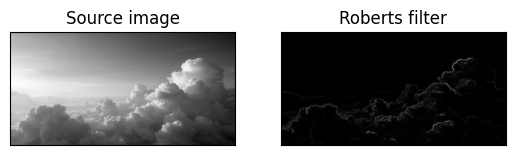

In [44]:
# Apply filter
Iroberts = RobertsFilter(I)
# Show the filtering result
ShowImages([("Source image", I), 
            ("Roberts filter", Iroberts)], 2)

### **4.2 Prewitt filter**

This approach uses two orthogonal masks of size $3\times 3$, allowing you to more accurately calculate the derivatives along the axes $Ox$ and $Oy$:

В этом подходе используются две ортогональные маски размером $3\times 3$, позволяющие более точно вычислить производные по осям $Ox$ и $Oy$:

$$
	G_x = 
	\begin{bmatrix}
		-1 & 0 & 1 \\
		-1 & 0 & 1 \\
		-1 & 0 & 1
	\end{bmatrix},
	G_y =
	\begin{bmatrix}
		-1 & -1 & -1 \\
		0 & 0 & 0 \\
		1 & 1 & 1
	\end{bmatrix}.
$$

Implementation is very similar to implementation of the Roberts filter.

Реализация очень похожа на реализацию фильтра Робертса.

#### **4.2.1 Self-work**

> ***Self-work***
>
> Implement the Prewitt filter and run it with the source image.
>
> ***Самостоятельная работа***
>
> Реализуйте фильтр Прюитта и запустите его на исходном изображении.


In [45]:
## The Prewitt filter
## @param[in] I An image to filter
## @return The filtered image

def PrewittFilter(I):
  # Convert to float
  if I.dtype == np.uint8:
    Iout = I.astype(np.float32) / 255.0
  else:
    Iout = I.copy()

  # Define kernels for X and Y
  kernel_x = np.array([[-1, 0, 1],
                       [-1, 0, 1],
                       [-1, 0, 1]], dtype=np.float32)
    
  kernel_y = np.array([[-1, -1, -1],
                       [0, 0, 0],
                       [1, 1, 1]], dtype=np.float32)

  # Perform convolution
  Ix = cv.filter2D(Iout, -1, kernel_x)
  Iy = cv.filter2D(Iout, -1, kernel_y)
  Iout = cv.magnitude(Ix, Iy)

  # Convert back to uint if needed
  if I.dtype == np.uint8:
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)
  
  # TODO Place your solution here

  return Iout

Now run it and check results.

Теперь запустите его и проверьте результаты.

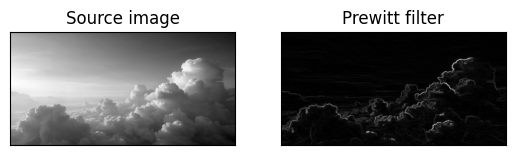

In [46]:
# Apply filter
Iprewitt = PrewittFilter(I)
# Show the filtering result
ShowImages([("Source image", I), 
            ("Prewitt filter", Iprewitt)], 2)

### **4.3 Sobel filter**

This approach is similar to the Roberts filter, but different mask weights are used. A typical example of a Sobel filter:

Этот подход аналогичен фильтру Робертса, но используются другие веса маски. Типичный пример фильтра Собеля:

$$
	G_x = 
	\begin{bmatrix}
		-1 & 0 & 1 \\
		-2 & 0 & 2 \\
		-1 & 0 & 1
	\end{bmatrix},
	G_y =
	\begin{bmatrix}
		1 & 2 & 1 \\
		0 & 0 & 0 \\
		-1 & -2 & -1
	\end{bmatrix}.
$$

This filter can be implemented manually as was described above or can use `cv2.Sobel(I, ddepth, dx, dy)` OpenCV function.

Этот фильтр можно реализовать вручную, как описано выше, или использовать функцию OpenCV `cv2.Sobel(I, ddepth, dx, dy)`.

#### **4.3.1 Self-work**

> ***Self-work***
>
> Implement the Sobel filter **without** using OpenCV `cv2.Sobel()` function. Run this filter with the source image.
>
> ***Самостоятельная работа***
>
> Реализуйте фильтр Собеля **без** использования функции OpenCV `cv2.Sobel()`. Запустите этот фильтр на исходном изображении.


In [38]:
## The Sobel filter
## @param[in] I An image to filter
## @return The filtered image
def SobelFilter(I):
  # Convert to float
  if I.dtype == np.uint8:
    Iout = I.astype(np.float32) / 255.0
  else:
    Iout = I.copy()

  # Define kernels for X and Y
  kernel_x = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]], dtype=np.float32)
  
  kernel_y = np.array([[1, 2, 1],
                      [0, 0, 0],
                      [-1, -2, -1]], dtype=np.float32)

  # Perform convolution
  Ix = cv.filter2D(Iout, -1, kernel_x)
  Iy = cv.filter2D(Iout, -1, kernel_y)
  Iout = cv.magnitude(Ix, Iy)

  # Convert back to uint if needed
  if I.dtype == np.uint8:
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)
  
  # TODO Place your solution here

  return Iout

Now run it and check results.

Теперь запустите его и проверьте результаты.

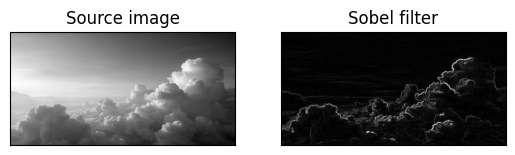

In [39]:
# Apply filter
Isobel = SobelFilter(I)
# Show the filtering result
ShowImages([("Source image", I), ("Sobel filter", Isobel)], 2)

### **4.4 Laplace filter**

Laplace filter uses approximation of the second derivatives along the axes $Ox$ and $Oy$ as opposed to previous approaches using the first derivative:

Фильтр Лапласа использует аппроксимацию вторых производных по осям $Ox$ и $Oy$, в отличие от предыдущих подходов, использующих первую производную:

| ![Laplace filter](images/laplace.png "Laplace filter") | 
|:--:| 
| *he second derivative of the brightness function changes sign (passes through zero at the point corresponding to the edge* |
| *Вторая производная функции яркости меняет знак (проходит через ноль в точке, соответствующей границе)* |

$$L(I(x,y)) = \frac{\partial^2 I}{\partial x^2}+\frac{\partial^2 I}{\partial y^2}$$

The above formula can be approximated by the following mask:

Вышеуказанную формулу можно аппроксимировать следующей маской:

$$
	w = 
	\begin{bmatrix}
		0 & -1 & 0 \\
		-1 & 4 & -1 \\
		0 & -1 & 0
	\end{bmatrix}
$$

Let's implement this filter according to a given forumla. It should be noted that this filter gives us the gradient, in other words, it can result in the negative values. For display purposes we will use the absolute value of the Laplace filter result (by applying `np.abs()` to the floating point value result before converting back to `uint8`). However in real cases this filter result should be used as is in floating point values for the further image processing steps.

There is the `cv2.Laplacian()` OpenCV function, however it **doesn't implement the Laplace filter**, *instead it uses the variation of the Sobel filter* along two axis with calculation of their magnitude. So it can't be used here.

Давайте реализуем этот фильтр в соответствии с заданной формулой. Следует отметить, что этот фильтр дает нам градиент, другими словами, он может давать отрицательные значения. Для целей отображения мы будем использовать абсолютное значение результата фильтра Лапласа (применяя `np.abs()` к результату со значениями с плавающей точкой перед преобразованием обратно в `uint8`). Однако в реальных случаях результат этого фильтра следует использовать как есть, в значениях с плавающей точкой, для дальнейших этапов обработки изображения.

Существует функция OpenCV `cv2.Laplacian()`, однако она **не реализует фильтр Лапласа**, *вместо этого она использует вариацию фильтра Собеля* по двум осям с вычислением их амплитуды. Так что здесь ее использовать нельзя.

#### **4.4.1 Self-work**

> **Self-work**
>
> Implement the Laplace filter **without** using OpenCV `cv2.Laplacian()` function. Don't forget to apply `np.abs()` to the result before converting it to $[0, 255]$ range. Run the Laplace filter implementation with the source image.
>
> **Самостоятельная работа**
>
> Реализуйте фильтр Лапласа **без** использования функции OpenCV `cv2.Laplacian()`. Не забудьте применить `np.abs()` к результату перед преобразованием его в диапазон $[0, 255]$. Запустите реализацию фильтра Лапласа на исходном изображении.


In [40]:
def LaplaceFilter(I):
  # Convert to float
  if I.dtype == np.uint8:
    Iout = I.astype(np.float32) / 255.0
  else:
    Iout = I.copy()

  # Define kernel
  kernel = np.array([[0, -1, 0],
                     [-1, 4, -1],
                     [0, -1, 0]], dtype=np.float32)

  # Perform convolution
  Iout = cv.filter2D(Iout, -1, kernel)
  Iout = np.abs(Iout)

  # Convert back to uint if needed
  if I.dtype == np.uint8:
    Iout = (255 * Iout).clip(0, 255).astype(np.uint8)
  
  # TODO Place your solution here

  return Iout

Now let's run it.

Теперь давайте запустим его.

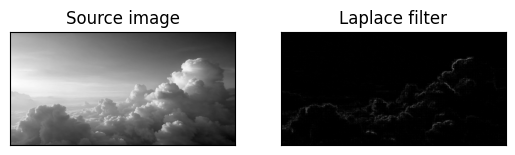

In [41]:
# Apply filter
Ilaplace = LaplaceFilter(I)
# Show the filtering result
ShowImages([("Source image", I), ("Laplace filter", Ilaplace)], 2)

### **4.5 Canny algorithm**

One of the most widespread and efficient algorithms for extracting edges in an image is *Canny algorithm*. This algorithm allows not only to define edge pixels, but also connected boundary lines. The algorithm consists of the following steps:

Одним из самых распространенных и эффективных алгоритмов выделения границ на изображении является *алгоритм Кэнни*. Этот алгоритм позволяет определить не только пиксели границ, но и связанные контурные линии. Алгоритм состоит из следующих шагов:

1. Elimination of small details by smoothing the original image using a Gaussian filter.
2. Using the Sobel differential operator to determine the values of the all image pixels gradient modulus, and the calculation result is rounded by steps $45^{\circ}$.
3. Analysis of the gradient modules values of the pixels located orthogonally to the investigated one. If the gradient modulus value of the investigated pixel is greater than orthogonal neighboring pixels, then it is *edge*, otherwise it is *non-maximum*.
4. Performing double threshold filtering of edge pixels selected in the previous step:
 - If the gradient modulus value greater the threshold $t_2$, then the edge presence in a pixel is valid.
 - If the gradient modulus value lower the threshold $t_1$, then the pixel is definitely not edge.
 - If the gradient modulus value in a range of $[t_1, t_2]$, then such a pixel is considered as \textit {ambiguous}.
5. Suppresses all ambiguous pixels not associated with valid pixels by 8-connectivity.

1. Устранение мелких деталей путем сглаживания исходного изображения с помощью фильтра Гаусса.
2. Использование дифференциального оператора Собеля для определения значений модуля градиента всех пикселей изображения, причем результат вычисления округляется с шагом $45^{\circ}$.
3. Анализ значений модулей градиента пикселей, расположенных ортогонально исследуемому. Если значение модуля градиента исследуемого пикселя больше, чем у ортогональных соседних пикселей, то он является *границей*, в противном случае он *не является максимумом*.
4. Выполнение двухпороговой фильтрации пикселей границ, выбранных на предыдущем шаге:
   - Если значение модуля градиента больше порога $t_2$, то наличие границы в пикселе считается достоверным.
   - Если значение модуля градиента ниже порога $t_1$, то пиксель точно не является границей.
   - Если значение модуля градиента находится в диапазоне $[t_1, t_2]$, то такой пиксель считается *неопределенным*.
5. Подавление всех неопределенных пикселей, не связанных с достоверными пикселями по 8-связности.

In OpenCV the Canny algorithm can be executed using `cv2.Canny(I, t1, t2)` function. `t1` and `t1` parameters define thresholding step thresholds.

В OpenCV алгоритм Кэнни можно выполнить с помощью функции `cv2.Canny(I, t1, t2)`. Параметры `t1` и `t2` определяют пороги этапа пороговой обработки.

In [ ]:
# Apply the Canny algorithm
Icanny = cv.Canny(I, 50, 220)
# Show the algorithm execution result
ShowImages([("Source image", I), 
            ("Canny algorithm", Icanny)], 2)

#### **4.5.1 Self-work**

> ***Self-work***
>
> Run the Canny algorithm for your image.
>
> ***Самостоятельная работа***
>
> Запустите алгоритм Кэнни для вашего изображения.


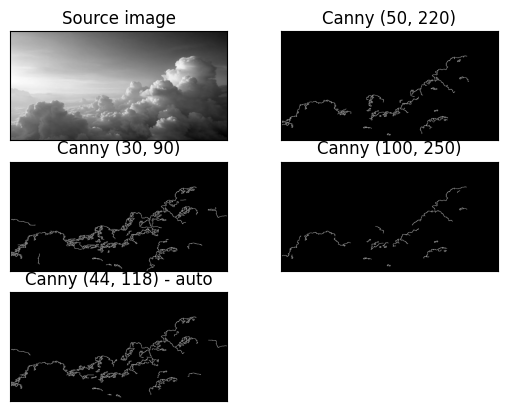

In [42]:
# TODO Place your solution for optional task here
# TODO Place your solution for optional task here
# TODO Place your solution for optional task here
Icanny = cv.Canny(I, 50, 220)
Icanny_low = cv.Canny(I, 30, 90)
Icanny_high = cv.Canny(I, 100, 250)

mean_intensity = np.mean(I)
low_threshold = int(0.3 * mean_intensity)
high_threshold = int(0.8 * mean_intensity)
Icanny_auto = cv.Canny(I, low_threshold, high_threshold)

ShowImages([
    ("Source image", I),
    ("Canny (50, 220)", Icanny),
    ("Canny (30, 90)", Icanny_low),
    ("Canny (100, 250)", Icanny_high),
    (f"Canny ({low_threshold}, {high_threshold}) - auto", Icanny_auto)
], 2)

### **4.6 High-pass filters summary**

Let's check all high-pass filter results side-by-side.

Давайте проверим результаты всех фильтров верхних частот рядом друг с другом.

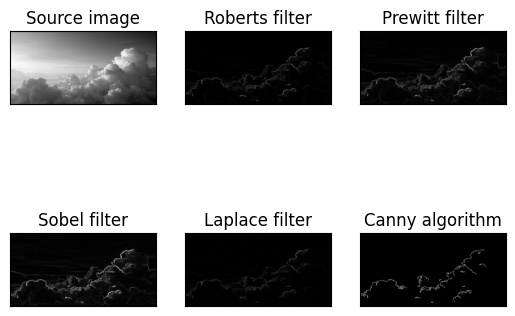

In [47]:
ShowImages([("Source image", I), 
            ("Roberts filter", Iroberts), 
            ("Prewitt filter", Iprewitt), 
            ("Sobel filter", Isobel), 
            ("Laplace filter", Ilaplace), 
            ("Canny algorithm", Icanny)], 3)

 ## Questions

Please answer the following questions:

Пожалуйста, ответьте на следующие вопросы:

 - What are the main disadvantages of adaptive image filtering methods?
 - Каковы основные недостатки адаптивных методов фильтрации изображений?
 > - Низкая производительность - для высокой точности требуется много вычислений.
 > - Сложнее в реализации, по сравнению с аналогами.
 > - Чувствительны к неправильной настройке. 
 
 - Which value of the $Q$ parameter will make the counterharmonic filter to work work as an arithmetic mean filter, and which value will make it a harmonic one?
 - Какое значение параметра $Q$ заставит контргармонический фильтр работать как фильтр среднего арифметического, а какое значение сделает его гармоническим?
 > $Q = 0$ - как фильтр среднего арифметического.
 > $Q = -1$ - как гармонический.
 
 - What operators can be used to detect edges in the image?
 - Какие операторы можно использовать для обнаружения границ на изображении?
 > Операторы Робертса, Прюитта, Собеля, Лапласа - от быстрого и менее эффективного к более медленным, но эффективным.
 > Алгоритм Кэнни - алгоритм, включающий сглаживание гауссовским фильтром, вычисление градиента оператором Собеля, подавление немаксимумов, двойную пороговую фильтрацию и трассировку границ по связности, позволяетполучать лучшие результаты.
 
 - Why, as a rule, is low-pass filtering performed at the first step of edge detection?
 - Почему, как правило, фильтрация нижних частот выполняется на первом этапе обнаружения границ?
 > - Градиентные операторы усиливают шум, поэтому предварительное сглаживание уменьшает влияние шума на результат
 > - Удаление высокочастотного шума повышает точность обнаружения реальных границ
 > - Без сглаживания мелкие детали и шум могут быть ошибочно определены как границы
 >
 


## Conclusion

What have you learned with this task? Don't forget to conclude it.

Что вы узнали, выполняя это задание? Не забудьте подвести итог.

>В ходе выполнения данной практической работы были  изучены основные методы фильтрации изображений и обнаружения границ, а также получены практические навыки работы с библиотеками OpenCV и NumPy.

>**1. Типы шумов и их моделирование**
>Были освоены методы генерации различных типов шумов: импульсного (соль/перец), спекл-шума, гауссовского и пуассоновского шума. Это позволило понять природу искажений, возникающих при получении и передаче изображений.

>**2. Фильтрация нижних частот (сглаживание)**
>Изучены и реализованы линейные фильтры:
>*   **Арифметический, геометрический, гармонический и контргармонический фильтры.** Экспериментально подтверждено, что контргармонический фильтр с положительным значением параметра Q (Q > 0) эффективен против шума типа "перец", а с отрицательным (Q < 0) — против шума типа "соль".
>*   **Гауссовский фильтр.** Показал наилучшие результаты при подавлении гауссовского шума, что соответствует теоретическим ожиданиям.

>**3. Нелинейная фильтрация**
>Рассмотрены и применены нелинейные методы:
>*   **Медианный фильтр.** Продемонстрировал высокую эффективность в удалении импульсного шума при одновременном сохранении резких границ объектов.
>*   **Ранговые фильтры (минимум и максимум).** Позволили изучить влияние экстремальных порядковых статистик на структуру изображения.
>*   **Адаптивный винеровский фильтр.** Подтвердил свою эффективность в условиях нестационарной статистики изображения, адаптируясь к локальным особенностям.

>**4. Фильтрация верхних частот (обнаружение границ)**
Реализованы основные дифференциальные операторы:
>*   **Операторы первого порядка:** Робертса, Прюитта, Собеля. Показано, что они чувствительны к шуму и требуют предварительного сглаживания.
>*   **Оператор второго порядка:** Лапласа. Выявил свою чувствительность к удвоению границ и шуму.
>*   **Алгоритм Кэнни.** Подтвердил свой статус одного из лучших детекторов границ, обеспечивая тонкие, связные и однопиксельные контуры благодаря многоэтапной обработке (сглаживание, вычисление градиента, подавление немаксимумов, двойная пороговая фильтрация).

>Таким образом, не существует единого универсального метода фильтрации, пригодного для всех типов изображений и задач. Выбор оптимального алгоритма всегда является компромиссом и определяется:
>*   Характером и интенсивностью шума.
>*   Требованиями к сохранению мелких деталей и текстур.
>*   Доступными вычислительными ресурсами.

>Практическая работа позволила не только закрепить теоретические знания о методах обработки изображений, но и приобрести важные навыки их программной реализации и сравнительного анализа эффективности.

